# False Positive / False Negative Exploration

Analysis of misclassified pairs from the OR-odorant interaction model.
- **FP**: model predicts interaction (pred=1), no experimental evidence (exp=0)
- **FN**: model misses a confirmed interaction (exp=1, pred=0)

Questions addressed:
1. Which receptors and odorants are most error-prone?
2. Are FPs/FNs enriched in Class I or Class II receptors?
3. Does mutation status affect misclassification?
4. Do FP/FN odorants differ chemically from correctly predicted ones?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

METADATA = 'metadata/exp_pred_common_pairs.csv'
OUT_DIR  = 'metadata'

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})
CAT_COLORS = {'TP': '#27ae60', 'TN': '#2980b9', 'FP': '#e74c3c', 'FN': '#f39c12'}

## 1. Load Data & Derive Categories

In [3]:
cp = pd.read_csv(METADATA)

def assign_cm(row):
    if row.experimental == 1 and row.predicted == 1: return 'TP'
    if row.experimental == 0 and row.predicted == 1: return 'FP'
    if row.experimental == 1 and row.predicted == 0: return 'FN'
    return 'TN'

cp['cm_category'] = cp.apply(assign_cm, axis=1)

# Subsets for convenience
fp = cp[cp.cm_category == 'FP']
fn = cp[cp.cm_category == 'FN']
tp = cp[cp.cm_category == 'TP']
tn = cp[cp.cm_category == 'TN']

print(f"Total pairs     : {len(cp):>7,}")
print(f"Unique proteins : {cp.uniprot_id.nunique():>7,}")
print(f"Unique SMILES   : {cp.smiles_id.nunique():>7,}")
print()
print("Confusion matrix:")
for cat in ['TP','FP','TN','FN']:
    n = (cp.cm_category == cat).sum()
    print(f"  {cat}: {n:>6,}  ({n/len(cp)*100:.1f}%)")

Total pairs     :  23,782
Unique proteins :     409
Unique SMILES   :     652

Confusion matrix:
  TP:  1,101  (4.6%)
  FP:  2,987  (12.6%)
  TN: 19,667  (82.7%)
  FN:     27  (0.1%)


## 2. Class Enrichment: Are FPs/FNs Enriched in Class I or Class II?

In [4]:
ct = pd.crosstab(cp.OR_class, cp.cm_category)[['TN','FP','TP','FN']]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Counts:")
print(ct.to_string())
print("\nRow percentages:")
print(ct_pct.round(2).to_string())

chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-square test: χ²={chi2:.2f}, p={p:.2e}, dof={dof}")

# Additional: FP rate per class
for cls in ['class 1', 'class 2']:
    sub = cp[cp.OR_class == cls]
    neg = sub[sub.experimental == 0]
    fp_rate = (neg.predicted == 1).sum() / len(neg) * 100
    print(f"  FP rate in {cls}: {fp_rate:.2f}% ({(neg.predicted==1).sum()}/{len(neg)} negatives)")

Counts:
cm_category     TN    FP   TP  FN
OR_class                         
class 1       2403   555  206   3
class 2      17264  2432  895  24

Row percentages:
cm_category     TN     FP    TP    FN
OR_class                             
class 1      75.88  17.52  6.50  0.09
class 2      83.74  11.80  4.34  0.12

Chi-square test: χ²=120.11, p=7.32e-26, dof=3
  FP rate in class 1: 18.76% (555/2958 negatives)
  FP rate in class 2: 12.35% (2432/19696 negatives)


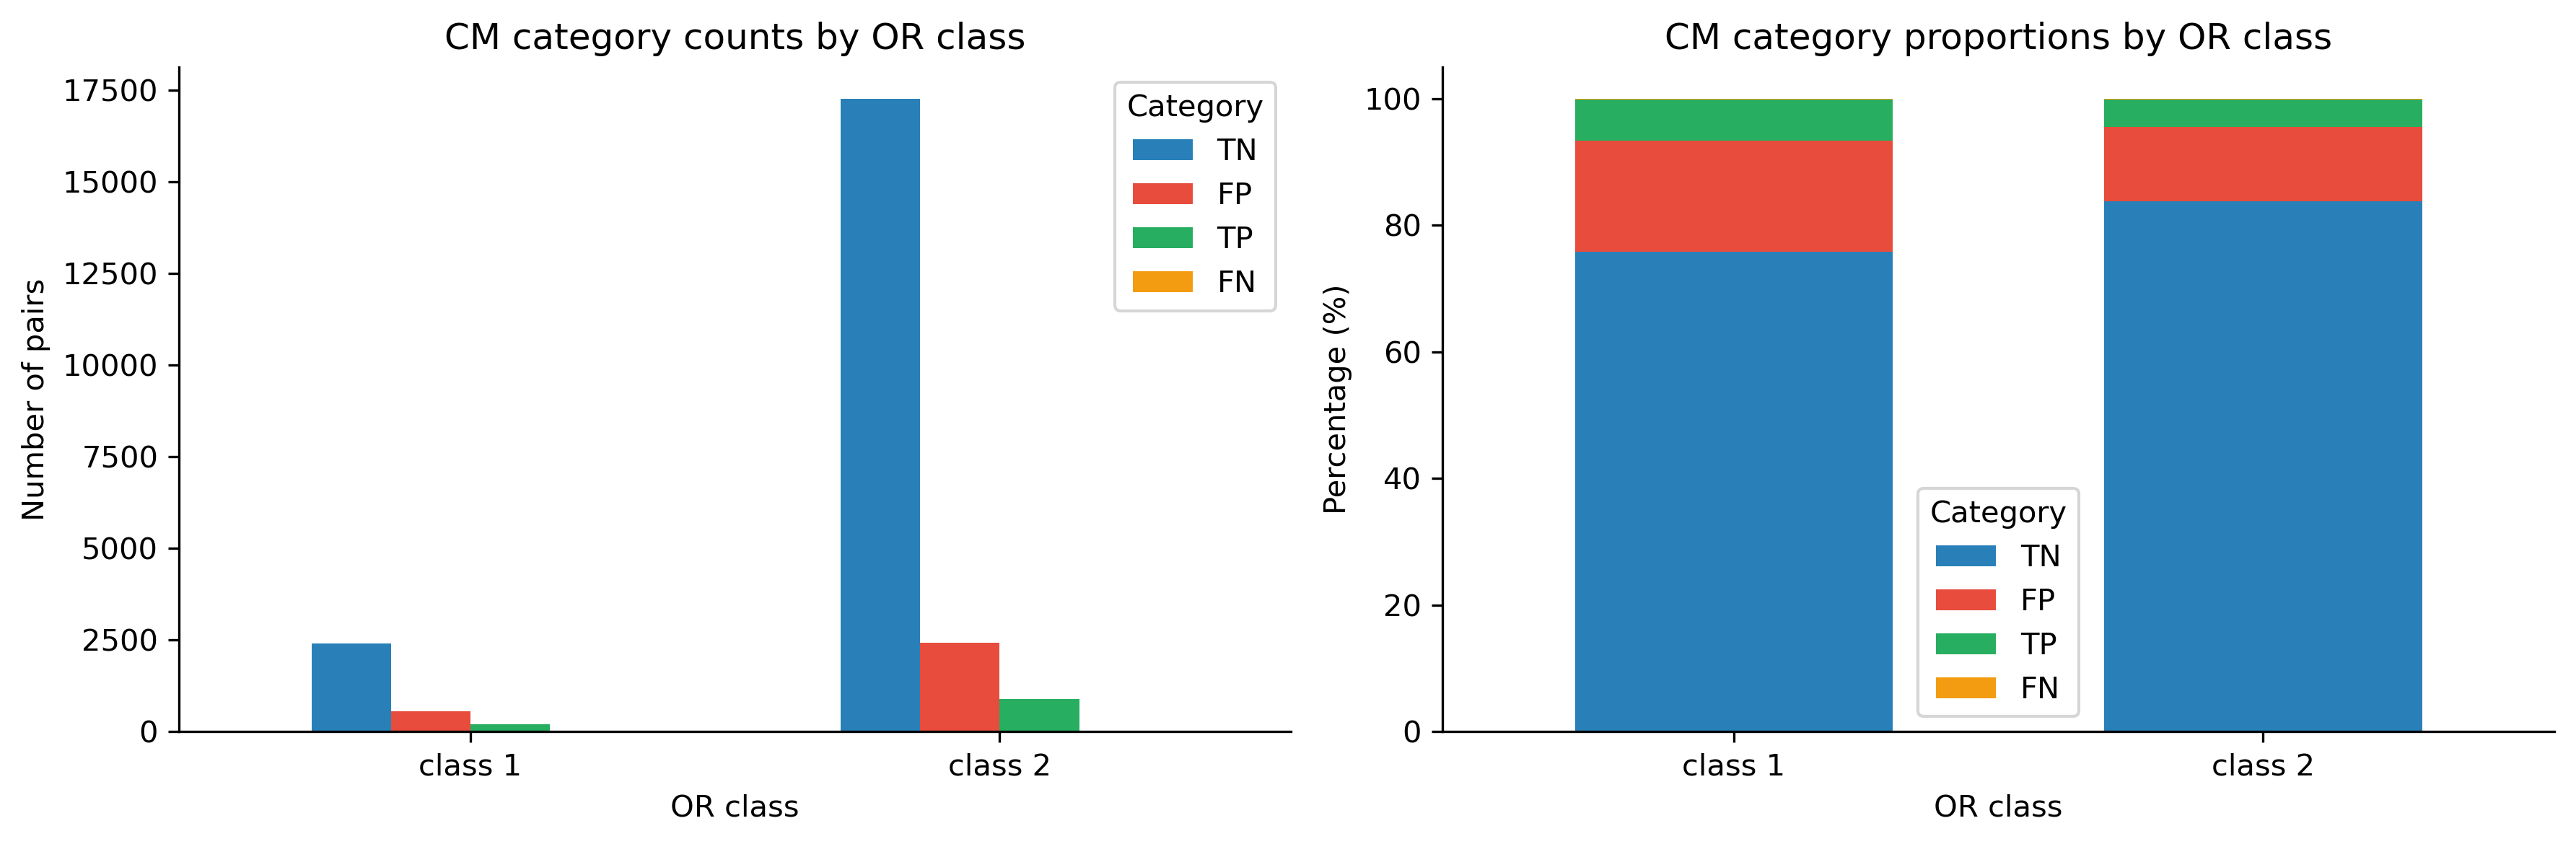

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stacked bar — raw counts
ct.plot(kind='bar', ax=axes[0], color=[CAT_COLORS[c] for c in ct.columns], width=0.6)
axes[0].set_xlabel('OR class')
axes[0].set_ylabel('Number of pairs')
axes[0].set_title('CM category counts by OR class')
axes[0].set_xticklabels(ct.index, rotation=0)
axes[0].legend(title='Category')

# Stacked bar — percentages (only FP + FN highlighted)
ct_pct.plot(kind='bar', ax=axes[1], color=[CAT_COLORS[c] for c in ct.columns], width=0.6, stacked=True)
axes[1].set_xlabel('OR class')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('CM category proportions by OR class')
axes[1].set_xticklabels(ct_pct.index, rotation=0)
axes[1].legend(title='Category')

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/class_cm_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Probability Distributions by CM Category

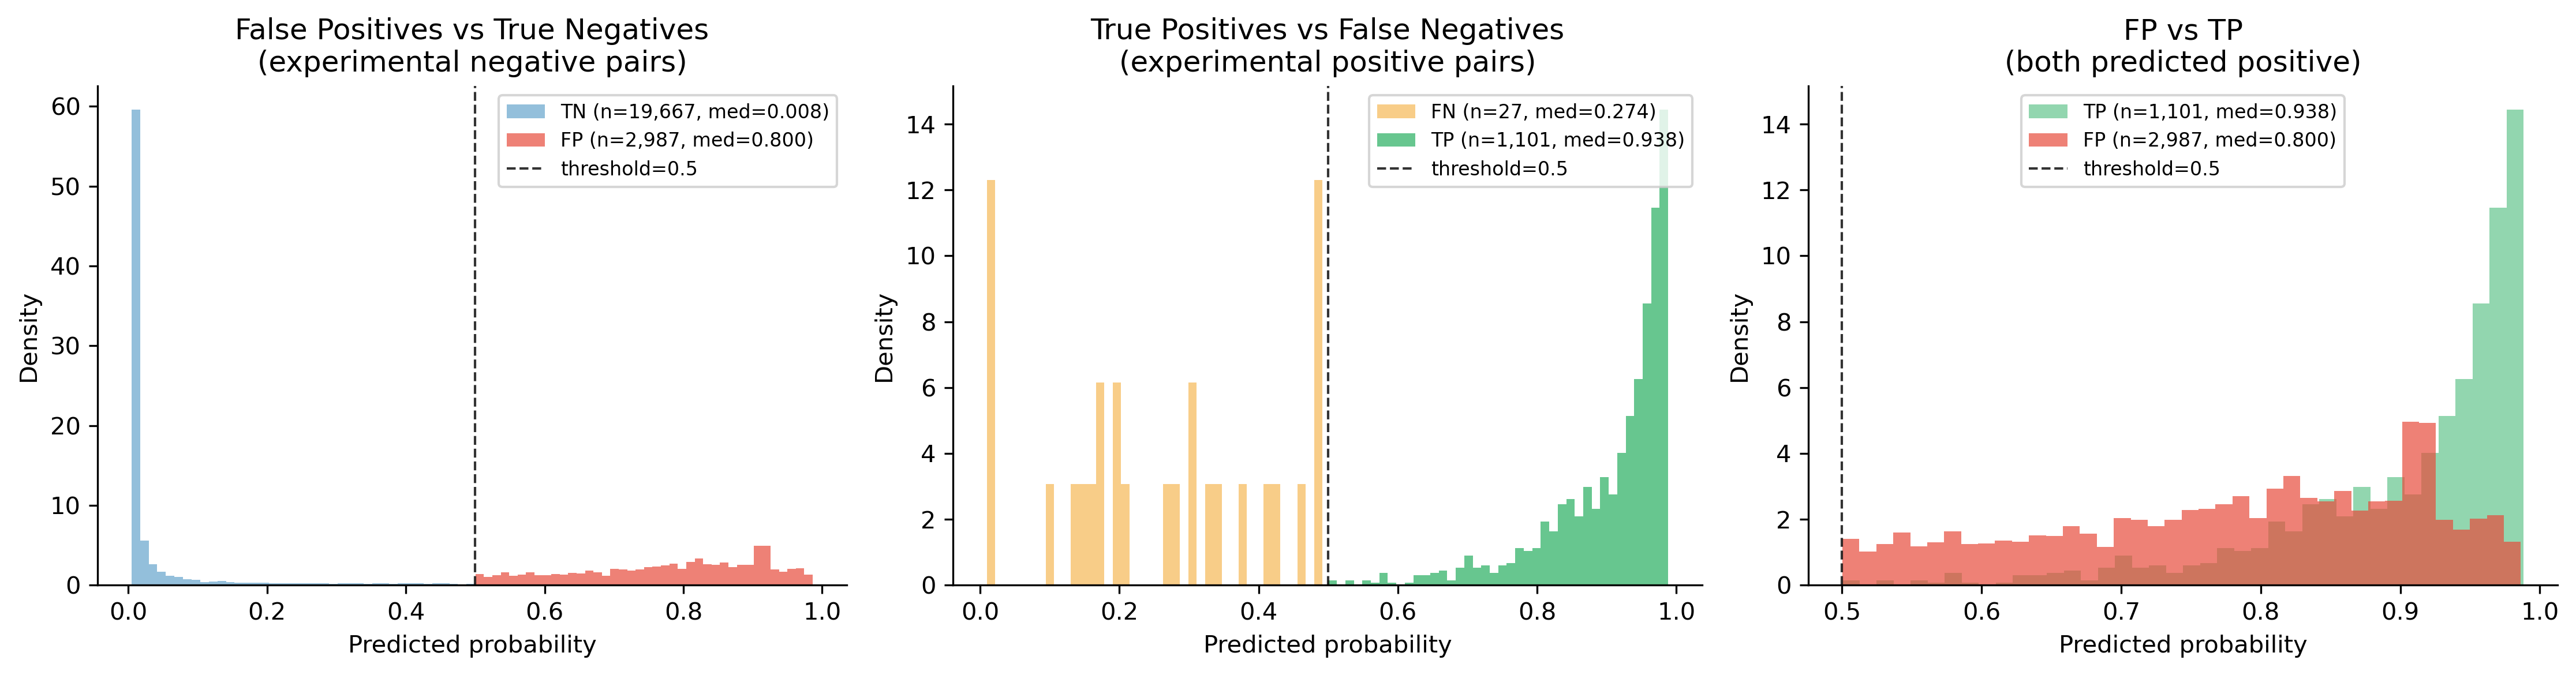

Probability summary by category:
               count    mean     std     min     25%     50%     75%     max
cm_category                                                                 
FN              27.0  0.2599  0.1598  0.0098  0.1595  0.2743  0.3999  0.4917
FP            2987.0  0.7789  0.1303  0.5003  0.6798  0.7999  0.8955  0.9863
TN           19667.0  0.0380  0.0838  0.0046  0.0060  0.0081  0.0183  0.4999
TP            1101.0  0.9049  0.0883  0.5003  0.8644  0.9381  0.9702  0.9883


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparisons = [
    ('FP', 'TN', 'False Positives vs True Negatives\n(experimental negative pairs)'),
    ('TP', 'FN', 'True Positives vs False Negatives\n(experimental positive pairs)'),
    ('FP', 'TP', 'FP vs TP\n(both predicted positive)'),
]

for ax, (grp1, grp2, title) in zip(axes, comparisons):
    for cat, alpha in [(grp2, 0.5), (grp1, 0.7)]:
        data = cp[cp.cm_category == cat]['probability']
        ax.hist(data, bins=40, alpha=alpha, color=CAT_COLORS[cat],
                label=f'{cat} (n={len(data):,}, med={data.median():.3f})', density=True)
    ax.axvline(0.5, color='k', linestyle='--', lw=1, alpha=0.8, label='threshold=0.5')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/probability_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Numeric summary
print("Probability summary by category:")
print(cp.groupby('cm_category')['probability'].describe().round(4).to_string())

## 4. FP Analysis — Per Receptor

In [7]:
receptor_stats = cp.groupby('uniprot_id').agg(
    total_pairs  = ('cm_category', 'count'),
    FP_count     = ('cm_category', lambda x: (x == 'FP').sum()),
    TN_count     = ('cm_category', lambda x: (x == 'TN').sum()),
    TP_count     = ('cm_category', lambda x: (x == 'TP').sum()),
    FN_count     = ('cm_category', lambda x: (x == 'FN').sum()),
    OR_class     = ('OR_class', 'first'),
    has_mutation = ('mutation', lambda x: x.any())
).reset_index()

# FP rate = FP / (FP + TN) = FP among negatives
receptor_stats['neg_pairs'] = receptor_stats.FP_count + receptor_stats.TN_count
receptor_stats['FP_rate']   = receptor_stats.FP_count / receptor_stats.neg_pairs
receptor_stats = receptor_stats.sort_values('FP_count', ascending=False)

print(f"Receptors with ≥1 FP : {(receptor_stats.FP_count > 0).sum()} / {len(receptor_stats)}")
print(f"Receptors with ≥1 FN : {(receptor_stats.FN_count > 0).sum()} / {len(receptor_stats)}")
print()
print("Top 20 receptors by FP count:")
display(receptor_stats[['uniprot_id','OR_class','total_pairs','neg_pairs','FP_count','FP_rate','has_mutation']].head(20).to_string(index=False))

Receptors with ≥1 FP : 395 / 409
Receptors with ≥1 FN : 24 / 409

Top 20 receptors by FP count:


'uniprot_id OR_class  total_pairs  neg_pairs  FP_count  FP_rate  has_mutation\n    Q9P1Q5  class 2          321        256       174 0.679688         False\n    Q9Y3N9  class 2          295        161       147 0.913043         False\n    Q9H346  class 1          162        130        99 0.761538         False\n    P47890  class 2          160        115        95 0.826087         False\n    Q9H255  class 1          196        166        67 0.403614         False\n    Q8NGG4  class 2          224        214        63 0.294393         False\n    P34982  class 2          181         78        61 0.782051         False\n    Q8NHB7  class 2          233        206        59 0.286408         False\n    Q9Y585  class 2          154        132        58 0.439394         False\n    Q8WZ94  class 2          132        118        42 0.355932         False\n    O76002  class 2          123        113        39 0.345133         False\n    Q8NGI9  class 2          107         72        39 0.541667 

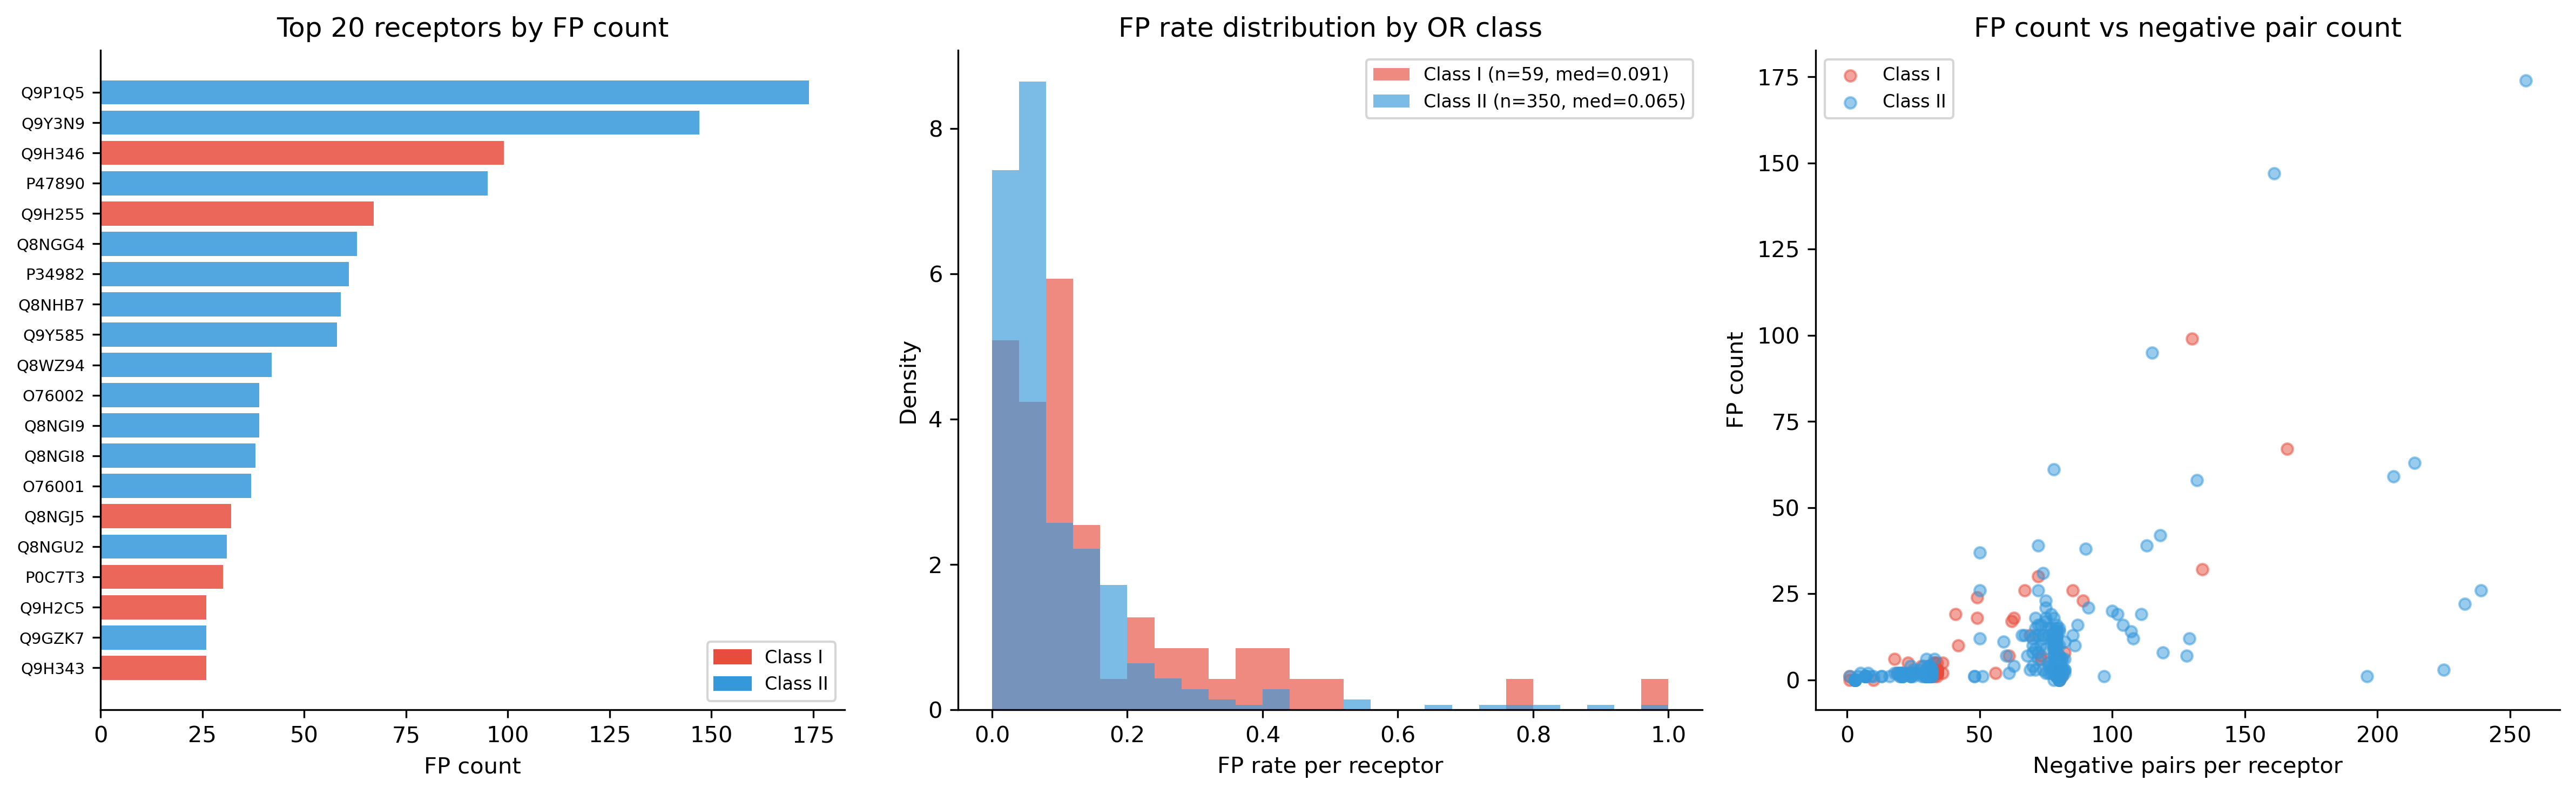

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Top 20 receptors by FP count
top20 = receptor_stats.head(20)
bar_colors = ['#e74c3c' if c == 'class 1' else '#3498db' for c in top20.OR_class]
axes[0].barh(range(20), top20.FP_count.values, color=bar_colors, alpha=0.85)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20.uniprot_id.values, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel('FP count')
axes[0].set_title('Top 20 receptors by FP count')
axes[0].legend(handles=[
    Patch(color='#e74c3c', label='Class I'),
    Patch(color='#3498db', label='Class II')
], loc='lower right', fontsize=8)

# FP rate distribution by class
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    data = receptor_stats[receptor_stats.OR_class == cls]['FP_rate'].dropna()
    axes[1].hist(data, bins=25, alpha=0.65, color=color,
                 label=f'{label} (n={len(data)}, med={data.median():.3f})', density=True)
axes[1].set_xlabel('FP rate per receptor')
axes[1].set_ylabel('Density')
axes[1].set_title('FP rate distribution by OR class')
axes[1].legend(fontsize=8)

# FP count vs total pairs (scatter)
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    sub = receptor_stats[receptor_stats.OR_class == cls]
    axes[2].scatter(sub.neg_pairs, sub.FP_count, alpha=0.5, color=color, s=25, label=label)
axes[2].set_xlabel('Negative pairs per receptor')
axes[2].set_ylabel('FP count')
axes[2].set_title('FP count vs negative pair count')
axes[2].legend(fontsize=8)

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/fp_per_receptor.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. FP Analysis — Per Odorant

In [9]:
odorant_stats = cp.groupby('smiles_id').agg(
    total_pairs = ('cm_category', 'count'),
    FP_count    = ('cm_category', lambda x: (x == 'FP').sum()),
    TN_count    = ('cm_category', lambda x: (x == 'TN').sum()),
    TP_count    = ('cm_category', lambda x: (x == 'TP').sum()),
    FN_count    = ('cm_category', lambda x: (x == 'FN').sum()),
    SMILES      = ('SMILES', 'first')
).reset_index()

odorant_stats['neg_pairs'] = odorant_stats.FP_count + odorant_stats.TN_count
odorant_stats['FP_rate']   = odorant_stats.FP_count / odorant_stats.neg_pairs
odorant_stats = odorant_stats.sort_values('FP_count', ascending=False)

print(f"Odorants with ≥1 FP : {(odorant_stats.FP_count > 0).sum()} / {len(odorant_stats)}")
print()
print("Top 20 odorants by FP count:")
pd.set_option('display.max_colwidth', 55)
display(odorant_stats[['smiles_id','total_pairs','FP_count','FP_rate','SMILES']].head(20))

Odorants with ≥1 FP : 410 / 652

Top 20 odorants by FP count:


,smiles_id,total_pairs,FP_count,FP_rate,SMILES
120,SML0120,273,267,0.992565,CC1COCC2=CC3=C(C=C12)C(C(C3(C)C)C)(C)C
89,SML0089,344,264,0.843450,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@@]3(C...
83,SML0083,187,137,0.878205,C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C
110,SML0110,186,97,0.664384,C/C=C/C1=CC(=C(C=C1)O)OC
85,SML0085,186,94,0.552941,CCCCCCC/C=C/C=O
103,SML0103,189,77,0.475309,CC(=CCC/C(=C/COC(=O)C)/C)C
100,SML0100,188,74,0.483660,CC(=O)OC1=C(C=C(C=C1)CC=C)OC
102,SML0102,191,65,0.359116,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)CC[C@]34C
77,SML0077,186,59,0.343023,CCCCCOC(=O)C
80,SML0080,161,58,0.394558,CC(=O)C1=CC=CC=C1


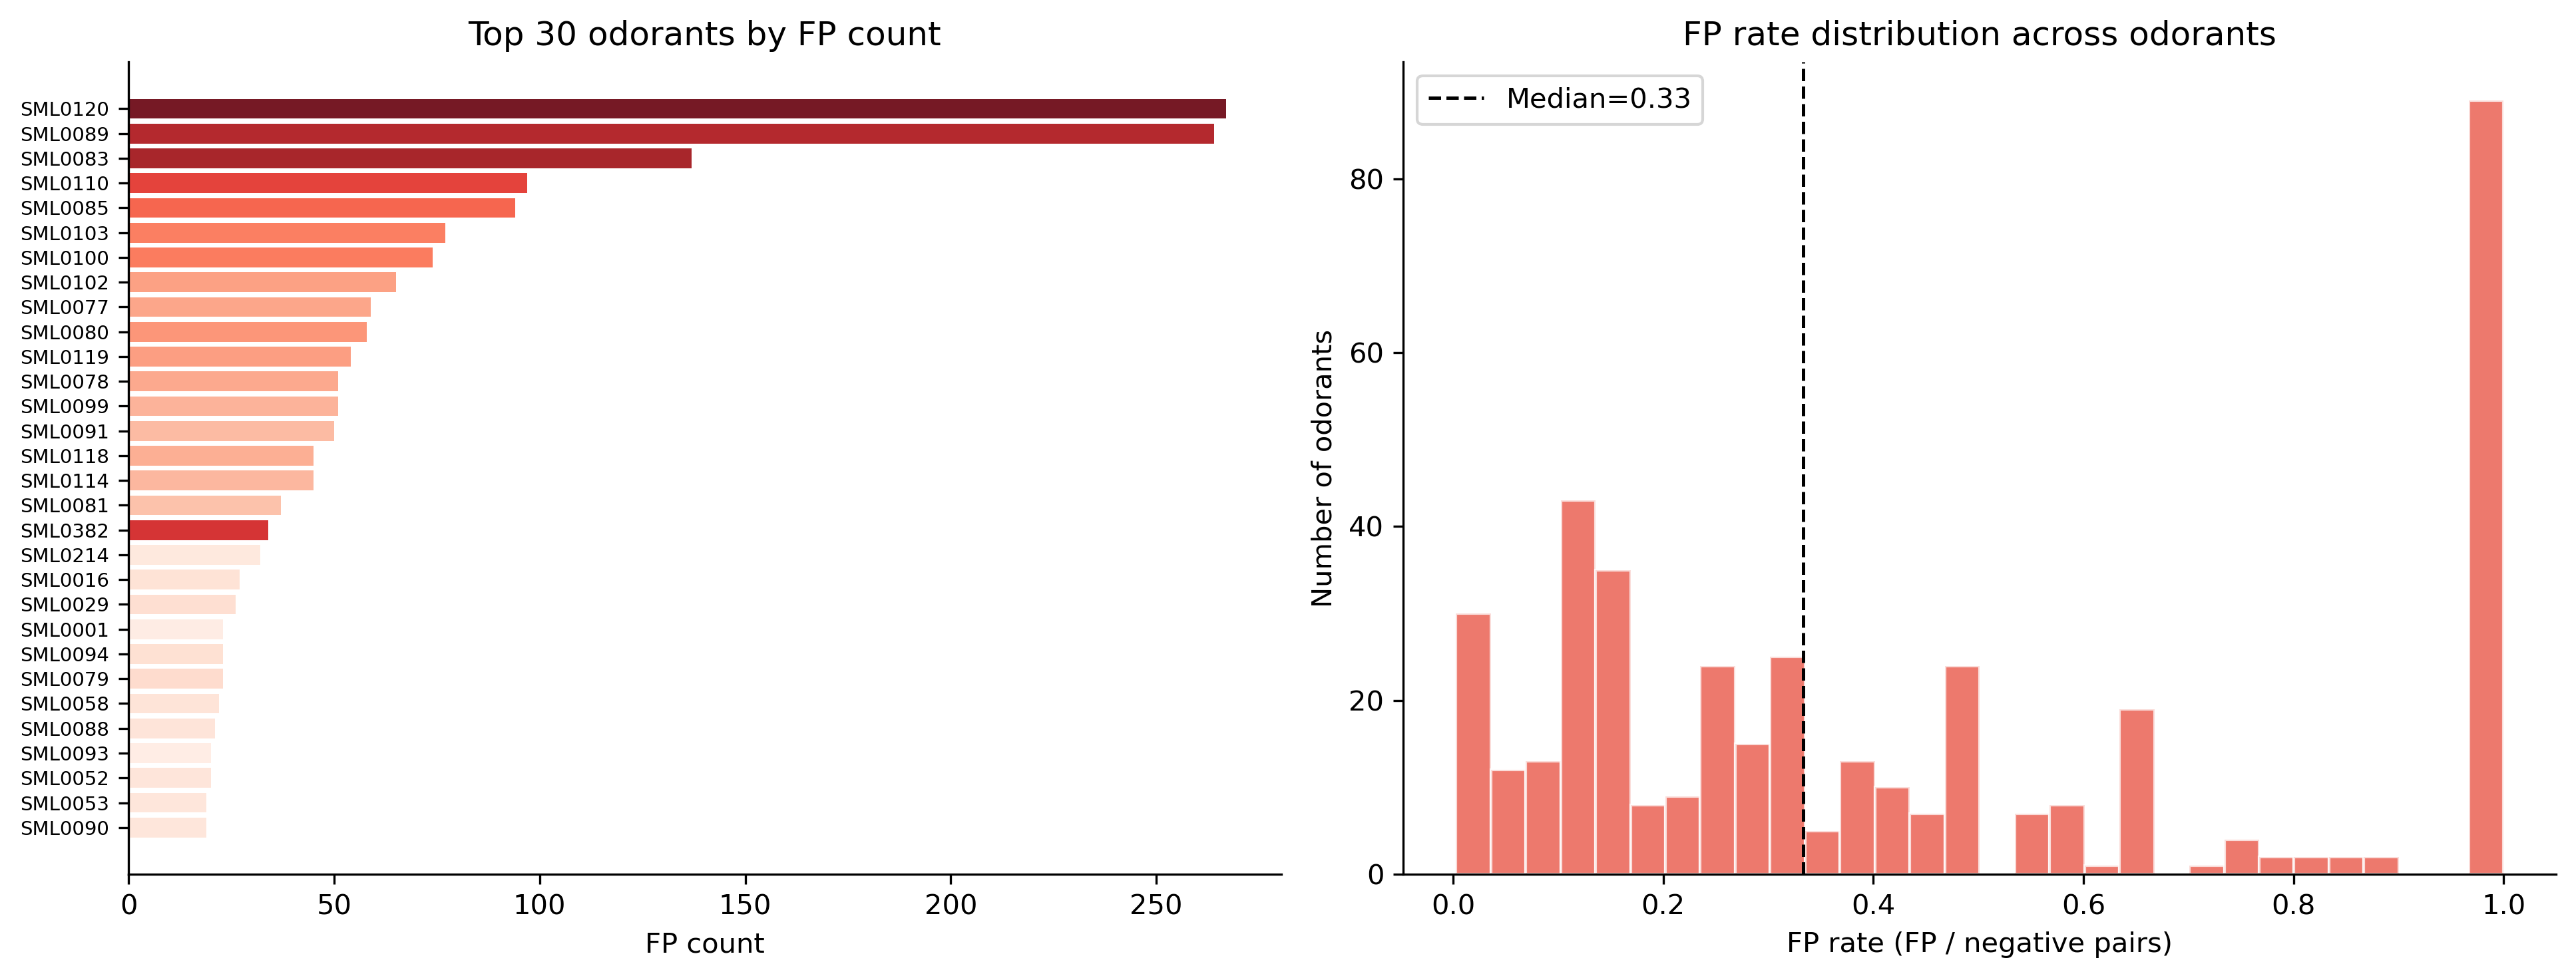

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top 30 odorants by FP count
top30 = odorant_stats.head(30)
cmap_vals = plt.cm.Reds(top30.FP_rate.values / top30.FP_rate.max())
axes[0].barh(range(30), top30.FP_count.values, color=cmap_vals, alpha=0.9)
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(top30.smiles_id.values, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel('FP count')
axes[0].set_title('Top 30 odorants by FP count')

# FP rate histogram across all odorants with ≥1 FP
fp_odo = odorant_stats[odorant_stats.FP_count > 0]
axes[1].hist(fp_odo.FP_rate, bins=30, color='#e74c3c', alpha=0.75, edgecolor='white')
axes[1].axvline(fp_odo.FP_rate.median(), color='k', ls='--', lw=1.2,
               label=f'Median={fp_odo.FP_rate.median():.2f}')
axes[1].set_xlabel('FP rate (FP / negative pairs)')
axes[1].set_ylabel('Number of odorants')
axes[1].set_title('FP rate distribution across odorants')
axes[1].legend()

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/fp_per_odorant.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. False Negatives — All 27 Pairs

In [11]:
print(f"All {len(fn)} False Negative pairs (confirmed interaction, model predicts no interaction)")
print("="*80)

fn_display = fn[['uniprot_id','OR_class','mutation','smiles_id','SMILES','probability']].copy()
fn_display = fn_display.sort_values('probability', ascending=False).reset_index(drop=True)

pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 30)
display(fn_display)

print(f"\nFN breakdown:")
print(f"  OR class : {fn.OR_class.value_counts().to_dict()}")
print(f"  Mutation : {fn.mutation.value_counts().to_dict()}")
print(f"  Unique proteins  : {fn.uniprot_id.nunique()}")
print(f"  Unique odorants  : {fn.smiles_id.nunique()}")
print(f"  Probability range: {fn.probability.min():.4f} – {fn.probability.max():.4f} (med={fn.probability.median():.4f})")

All 27 False Negative pairs (confirmed interaction, model predicts no interaction)


,uniprot_id,OR_class,mutation,smiles_id,SMILES,probability
0,Q8NH16,class 2,False,SML0016,CCCC(=O)O,0.491723
1,Q6IEV9,class 2,False,SML0079,CCCCCC(=O)C,0.491094
2,Q96R27,class 2,False,SML0595,CC1=CC=C(C=C1)OC,0.484748
3,Q8NGU2,class 2,False,SML0104,COC1=CC=CC=C1O,0.480335
4,Q8NGU2,class 2,False,SML0108,CC(C)C=O,0.461305
5,Q13606,class 2,False,SML0104,COC1=CC=CC=C1O,0.422383
6,Q96RD3,class 1,False,SML0109,CC(C)C(=O)O,0.417762
7,Q8NGJ5,class 1,False,SML0111,CS,0.382087
8,Q8NG83,class 2,False,SML0080,CC(=O)C1=CC=CC=C1,0.338247
9,Q8NG81,class 2,False,SML0087,CC1=CC(=C(C=C1)O)OC,0.333687



FN breakdown:
  OR class : {'class 2': 24, 'class 1': 3}
  Mutation : {False: 25, True: 2}
  Unique proteins  : 24
  Unique odorants  : 19
  Probability range: 0.0098 – 0.4917 (med=0.2743)


In [12]:
# Which proteins appear multiple times in FN pairs?
fn_prot = fn.groupby('uniprot_id').agg(
    FN_count = ('cm_category', 'count'),
    OR_class = ('OR_class', 'first'),
    mutation = ('mutation', lambda x: x.any()),
    odorants = ('smiles_id', lambda x: ', '.join(x.tolist()))
).reset_index().sort_values('FN_count', ascending=False)

print("Proteins in FN pairs (by frequency):")
display(fn_prot)

# How many of these proteins also have TP pairs?
fn_prots_with_tp = set(fn.uniprot_id) & set(tp.uniprot_id)
print(f"\nFN proteins that also have TP pairs: {len(fn_prots_with_tp)} / {fn.uniprot_id.nunique()}")

Proteins in FN pairs (by frequency):


,uniprot_id,FN_count,OR_class,mutation,odorants
15,Q8NGU2,2,class 2,False,"SML0104, SML0108"
19,Q8WZ84,2,class 2,False,"SML0050, SML0246"
11,Q8NGP4,2,class 2,False,"SML0128, SML0302"
0,O76002,1,class 2,False,SML0088
4,Q6IEV9,1,class 2,False,SML0079
1,P47893,1,class 2,False,SML0108
2,Q13606,1,class 2,False,SML0104
3,Q15619,1,class 2,False,SML0032
7,Q8NG81,1,class 2,False,SML0087
6,Q8NG78,1,class 2,False,SML0079



FN proteins that also have TP pairs: 15 / 24


## 7. Chemical Properties of FP/FN Odorants vs Correctly Predicted

In [13]:
DESC_COLS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'RingCount', 'AromaticRings']

def compute_descriptors(smiles_str):
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return {k: np.nan for k in DESC_COLS}
    return {
        'MW'          : Descriptors.MolWt(mol),
        'logP'        : Descriptors.MolLogP(mol),
        'TPSA'        : Descriptors.TPSA(mol),
        'HBD'         : rdMolDescriptors.CalcNumHBD(mol),
        'HBA'         : rdMolDescriptors.CalcNumHBA(mol),
        'RotBonds'    : rdMolDescriptors.CalcNumRotatableBonds(mol),
        'RingCount'   : rdMolDescriptors.CalcNumRings(mol),
        'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
    }

unique_smiles = cp[['smiles_id','SMILES']].drop_duplicates('smiles_id')
desc_rows = []
for _, row in unique_smiles.iterrows():
    d = compute_descriptors(row.SMILES)
    d['smiles_id'] = row.smiles_id
    desc_rows.append(d)

smiles_desc = pd.DataFrame(desc_rows)
cp_desc = cp.merge(smiles_desc, on='smiles_id', how='left')

print(f"Descriptors computed for {len(smiles_desc)} unique SMILES")
print(f"Failed (None mol): {smiles_desc[DESC_COLS].isna().any(axis=1).sum()}")
print()
print(smiles_desc[DESC_COLS].describe().round(2).to_string())

Descriptors computed for 652 unique SMILES
Failed (None mol): 0

            MW    logP    TPSA     HBD     HBA  RotBonds  RingCount  AromaticRings
count   652.00  652.00  652.00  652.00  652.00    652.00     652.00         652.00
mean    164.06    2.35   28.27    0.50    1.71      3.34       0.76           0.36
std      63.52    1.45   26.98    0.97    1.21      3.15       0.86           0.57
min      44.05   -5.55    0.00    0.00    0.00      0.00       0.00           0.00
25%     130.19    1.59   17.07    0.00    1.00      1.00       0.00           0.00
50%     154.25    2.34   23.79    0.00    1.00      3.00       1.00           0.00
75%     187.52    3.10   34.14    1.00    2.00      5.00       1.00           1.00
max    1060.23    6.81  418.78   12.00   13.00     27.00       5.00           3.00


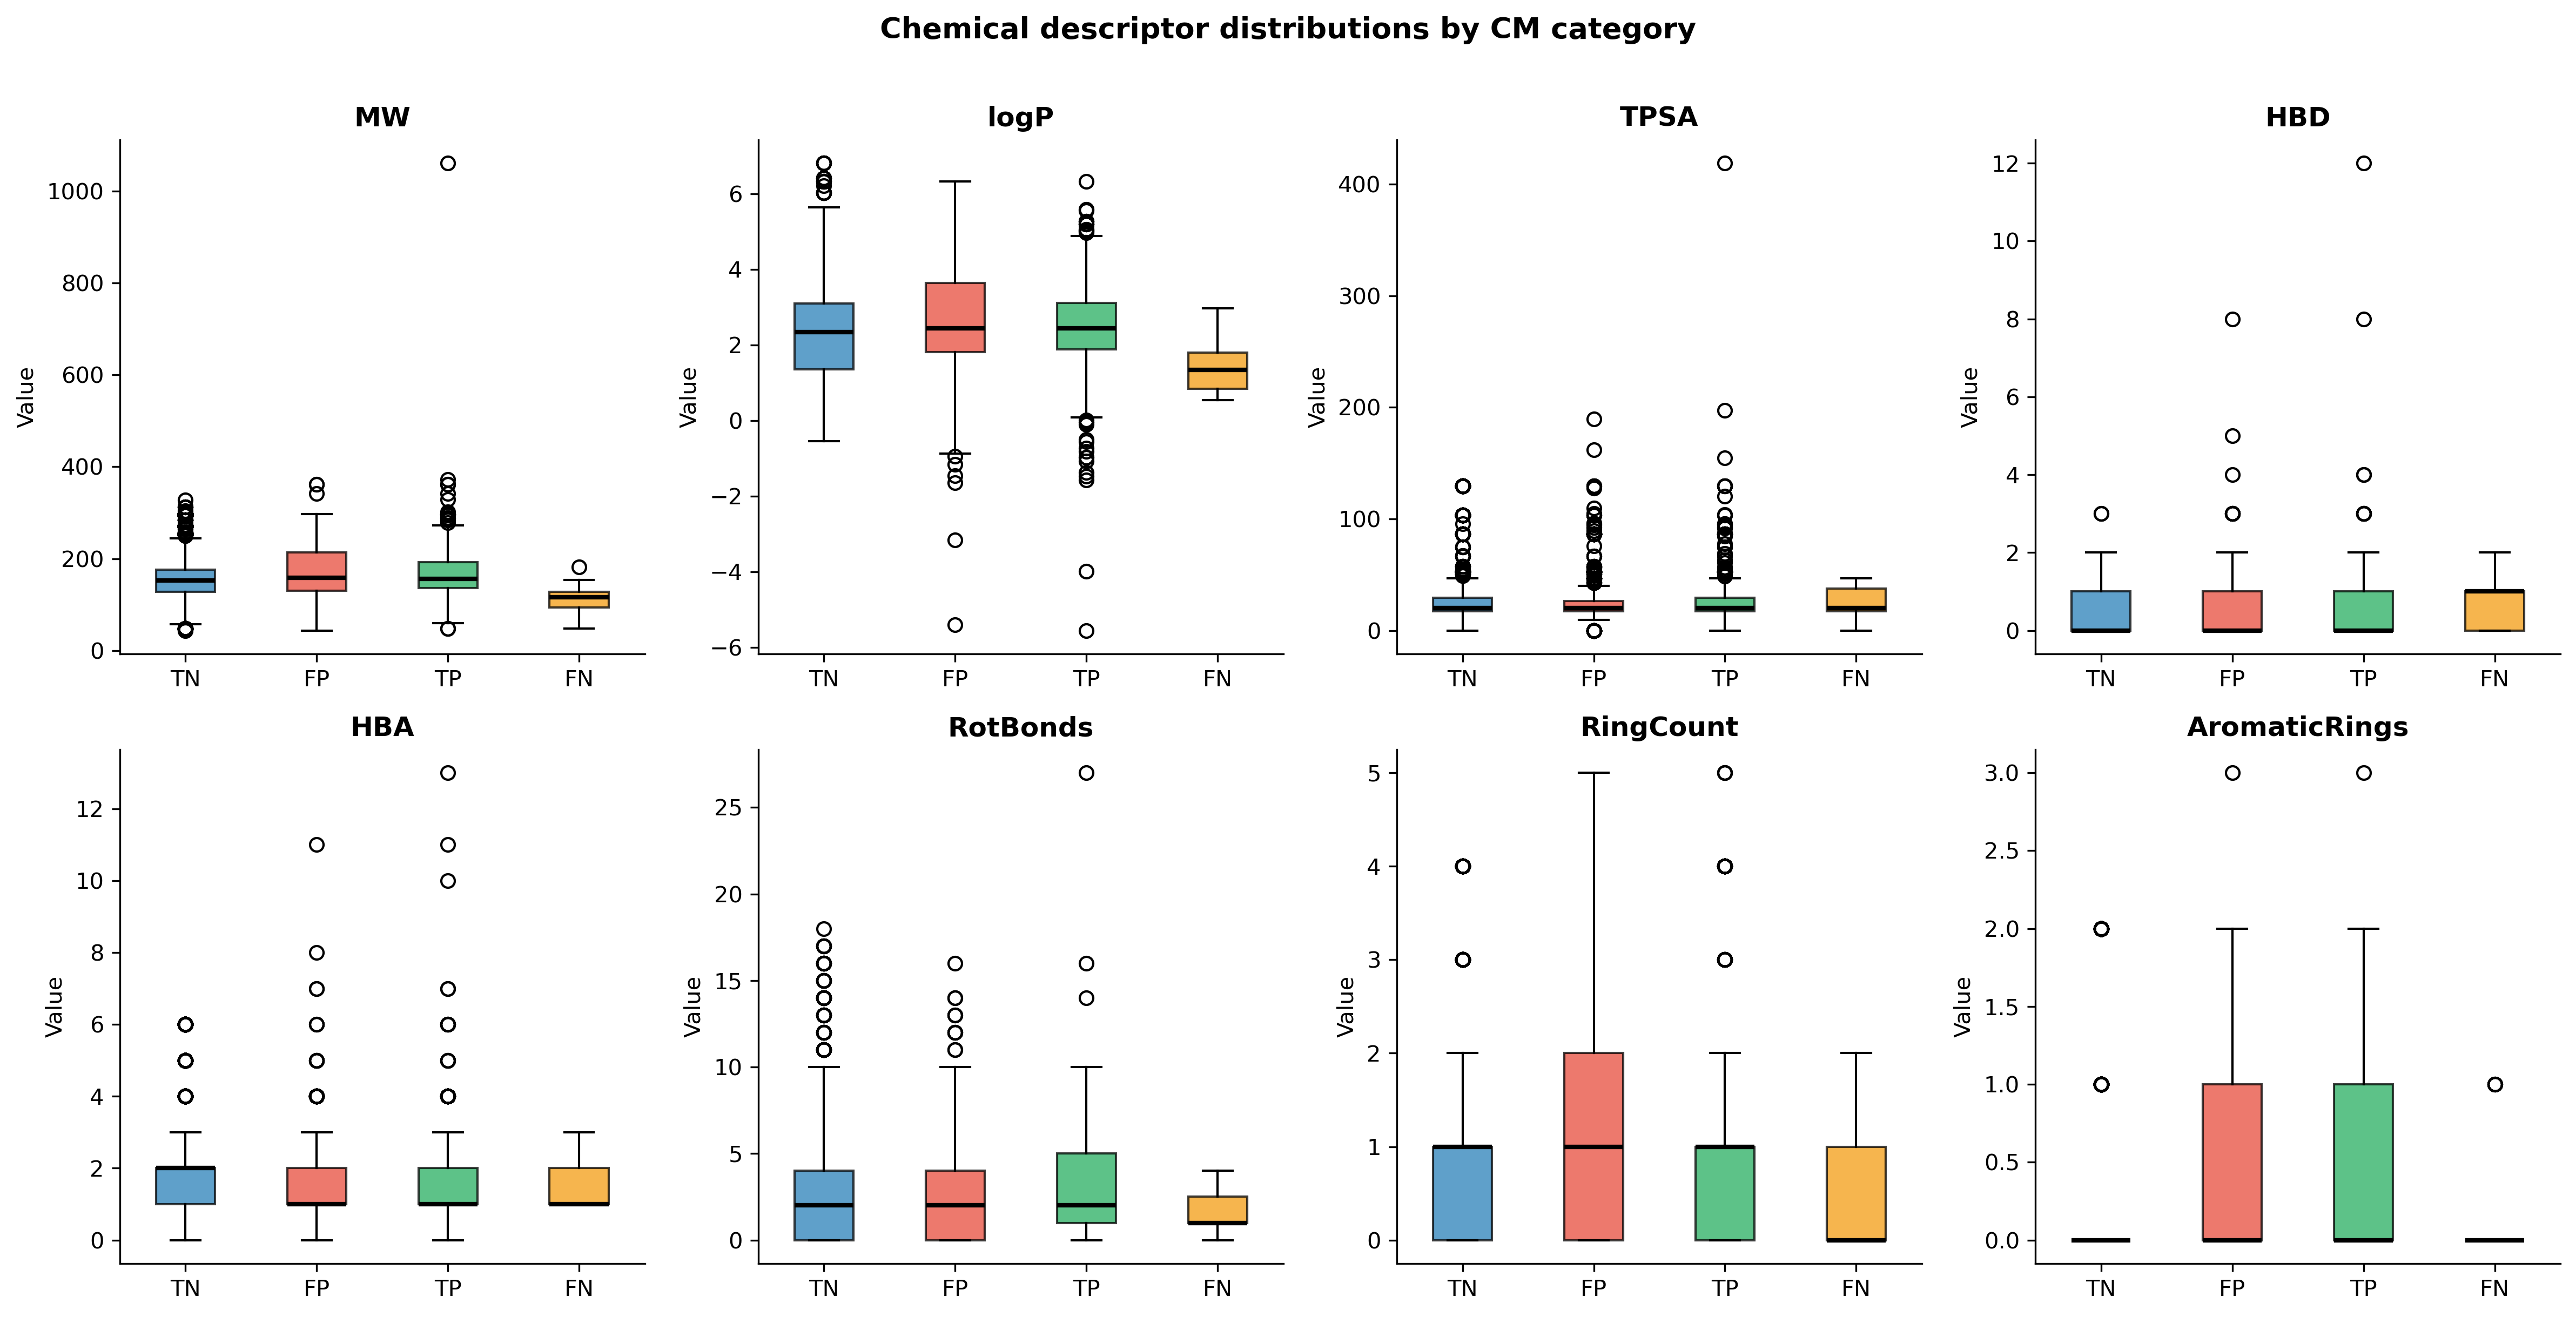

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cats_plot = ['TN', 'FP', 'TP', 'FN']

for i, desc in enumerate(DESC_COLS):
    data = [cp_desc[cp_desc.cm_category == cat][desc].dropna().values for cat in cats_plot]
    bp = axes[i].boxplot(data, labels=cats_plot, patch_artist=True, notch=False,
                         medianprops={'color':'black','linewidth':2})
    for patch, cat in zip(bp['boxes'], cats_plot):
        patch.set_facecolor(CAT_COLORS[cat])
        patch.set_alpha(0.75)
    axes[i].set_title(desc, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Chemical descriptor distributions by CM category', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/chemical_descriptors_by_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
print("Mann-Whitney U test: FP vs TN odorant chemical properties")
print(f"{'Descriptor':<14} {'FP_median':>10} {'TN_median':>10} {'p-value':>12} {'sig':>5}")
print("-" * 55)
for desc in DESC_COLS:
    fp_d = cp_desc[cp_desc.cm_category == 'FP'][desc].dropna()
    tn_d = cp_desc[cp_desc.cm_category == 'TN'][desc].dropna()
    _, p = mannwhitneyu(fp_d, tn_d, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{desc:<14} {fp_d.median():>10.3f} {tn_d.median():>10.3f} {p:>12.4e} {sig:>5}")

print()
print("Kruskal-Wallis test across all four CM categories:")
print(f"{'Descriptor':<14} {'H':>8} {'p-value':>12} {'sig':>5}")
print("-" * 42)
for desc in DESC_COLS:
    groups = [cp_desc[cp_desc.cm_category == cat][desc].dropna().values for cat in cats_plot]
    h, p = kruskal(*groups)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{desc:<14} {h:>8.2f} {p:>12.4e} {sig:>5}")

Mann-Whitney U test: FP vs TN odorant chemical properties
Descriptor      FP_median  TN_median      p-value   sig
-------------------------------------------------------
MW                158.241    152.237   1.7157e-48   ***
logP                2.440      2.349   2.6266e-53   ***
TPSA               20.230     20.230   4.7705e-27   ***
HBD                 0.000      0.000   7.0138e-32   ***
HBA                 1.000      2.000   1.3280e-48   ***
RotBonds            2.000      2.000   1.6327e-01    ns
RingCount           1.000      1.000   9.6952e-66   ***
AromaticRings       0.000      0.000   8.4549e-27   ***

Kruskal-Wallis test across all four CM categories:
Descriptor            H      p-value   sig
------------------------------------------
MW               267.36   1.1519e-57   ***
logP             300.35   8.3666e-65   ***
TPSA             116.85   3.6722e-25   ***
HBD              173.23   2.5509e-37   ***
HBA              225.99   1.0167e-48   ***
RotBonds          90.28   1.9

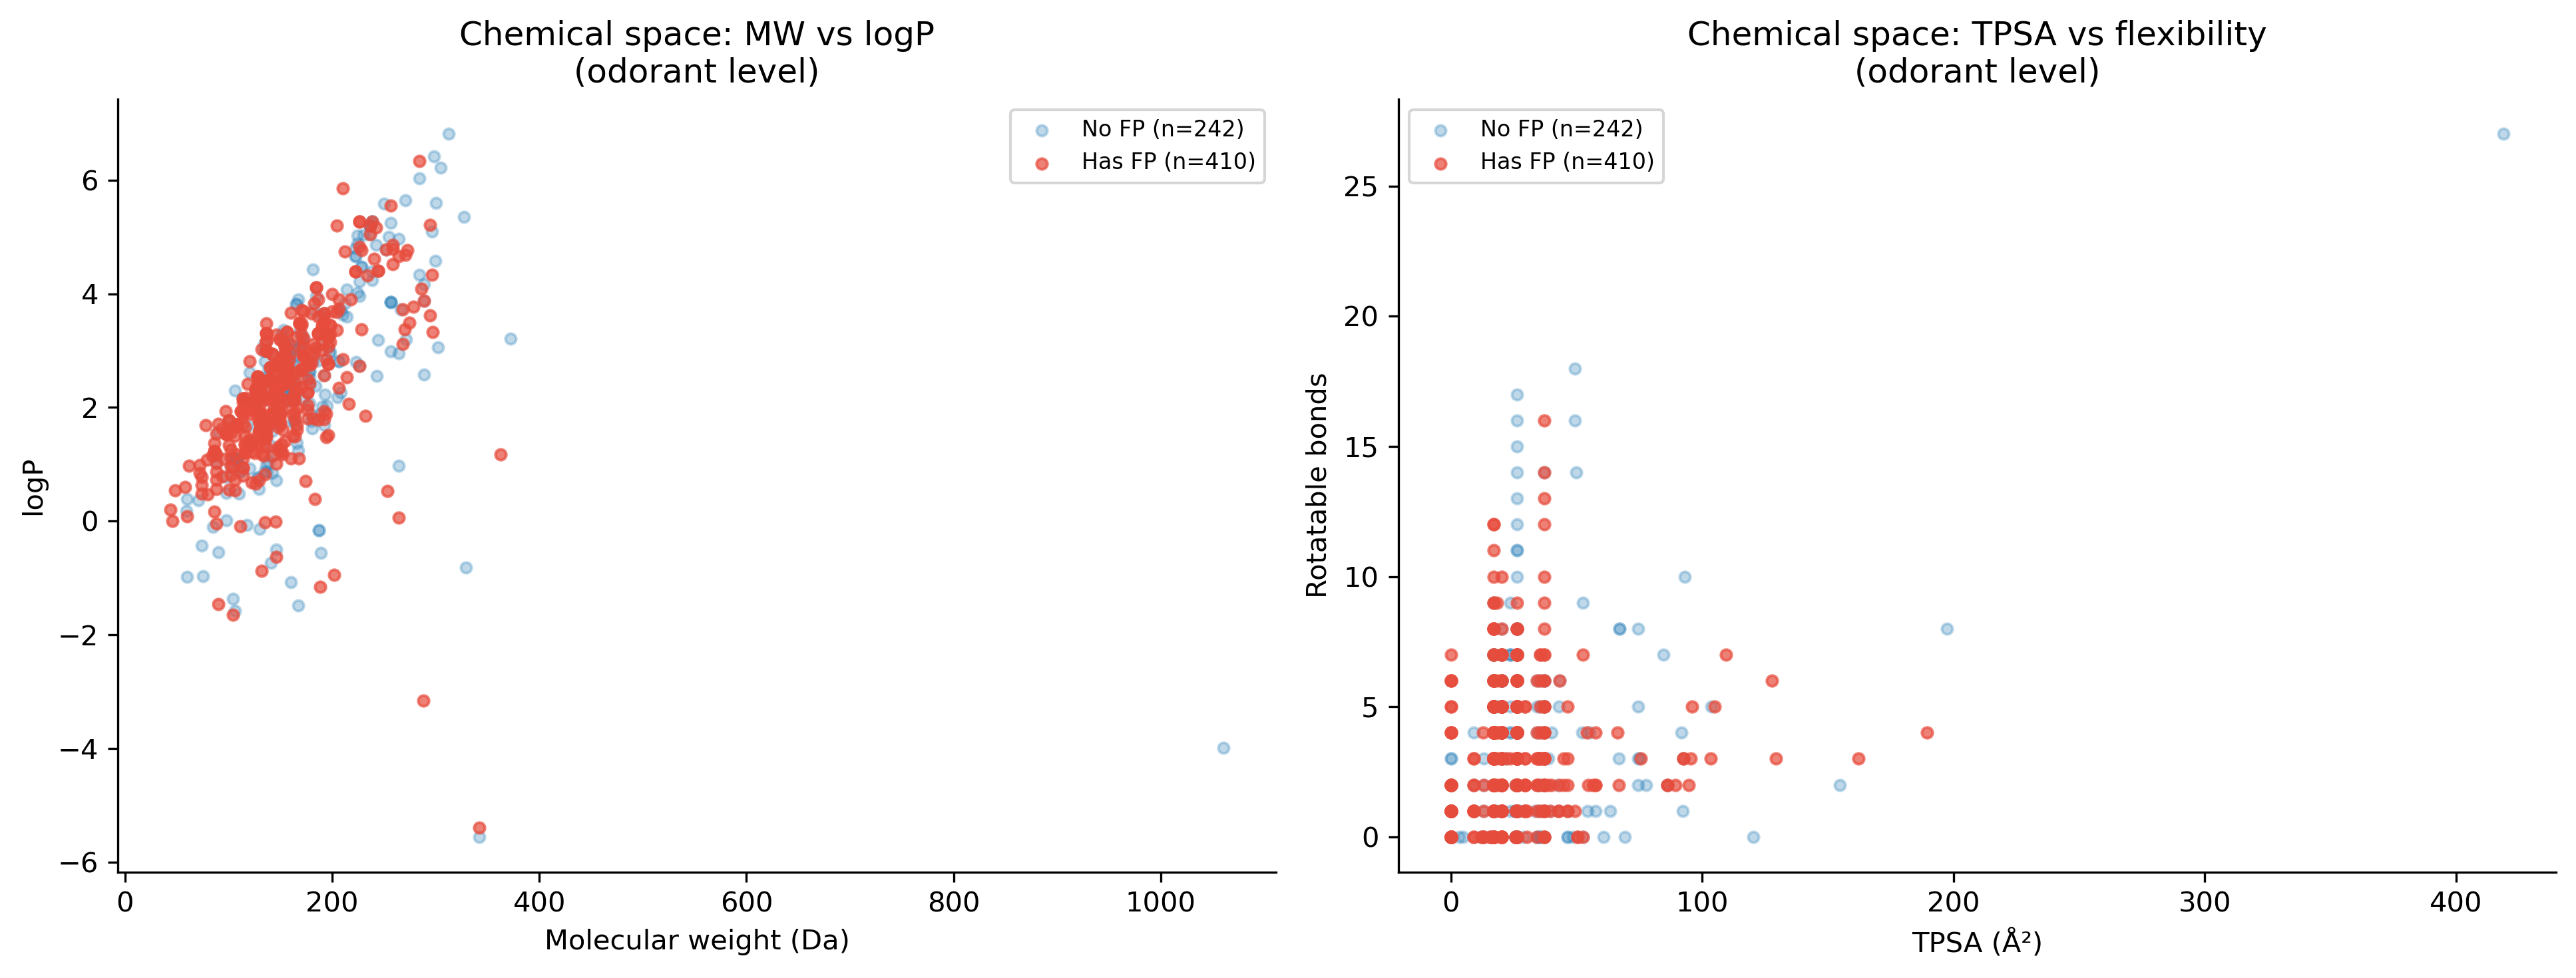

In [16]:
# Chemical space 2D — FP vs TN odorants at the unique-SMILES level
# Aggregate: each SMILES gets the category of its most frequent pair type
smiles_cat = cp_desc.groupby('smiles_id').agg(
    FP_count = ('cm_category', lambda x: (x=='FP').sum()),
    TN_count = ('cm_category', lambda x: (x=='TN').sum()),
).reset_index()
smiles_cat['dominant'] = np.where(smiles_cat.FP_count > smiles_cat.TN_count, 'FP-dominant', 'TN-dominant')
# Odorants with any FP vs purely TN
smiles_cat['has_FP'] = smiles_cat.FP_count > 0

plot_df = smiles_cat.merge(smiles_desc, on='smiles_id')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for has_fp, label, color, alpha in [
    (False, 'No FP',  '#2980b9', 0.3),
    (True,  'Has FP', '#e74c3c', 0.7)
]:
    sub = plot_df[plot_df.has_FP == has_fp]
    axes[0].scatter(sub.MW, sub.logP, c=color, alpha=alpha, s=15, label=f'{label} (n={len(sub)})')
axes[0].set_xlabel('Molecular weight (Da)')
axes[0].set_ylabel('logP')
axes[0].set_title('Chemical space: MW vs logP\n(odorant level)')
axes[0].legend(fontsize=8)

for has_fp, label, color, alpha in [
    (False, 'No FP',  '#2980b9', 0.3),
    (True,  'Has FP', '#e74c3c', 0.7)
]:
    sub = plot_df[plot_df.has_FP == has_fp]
    axes[1].scatter(sub.TPSA, sub.RotBonds, c=color, alpha=alpha, s=15, label=f'{label} (n={len(sub)})')
axes[1].set_xlabel('TPSA (Å²)')
axes[1].set_ylabel('Rotatable bonds')
axes[1].set_title('Chemical space: TPSA vs flexibility\n(odorant level)')
axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/chemical_space_fp_vs_tn.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Receptor-Level Heatmap: FP Rate by Receptor × OR Class

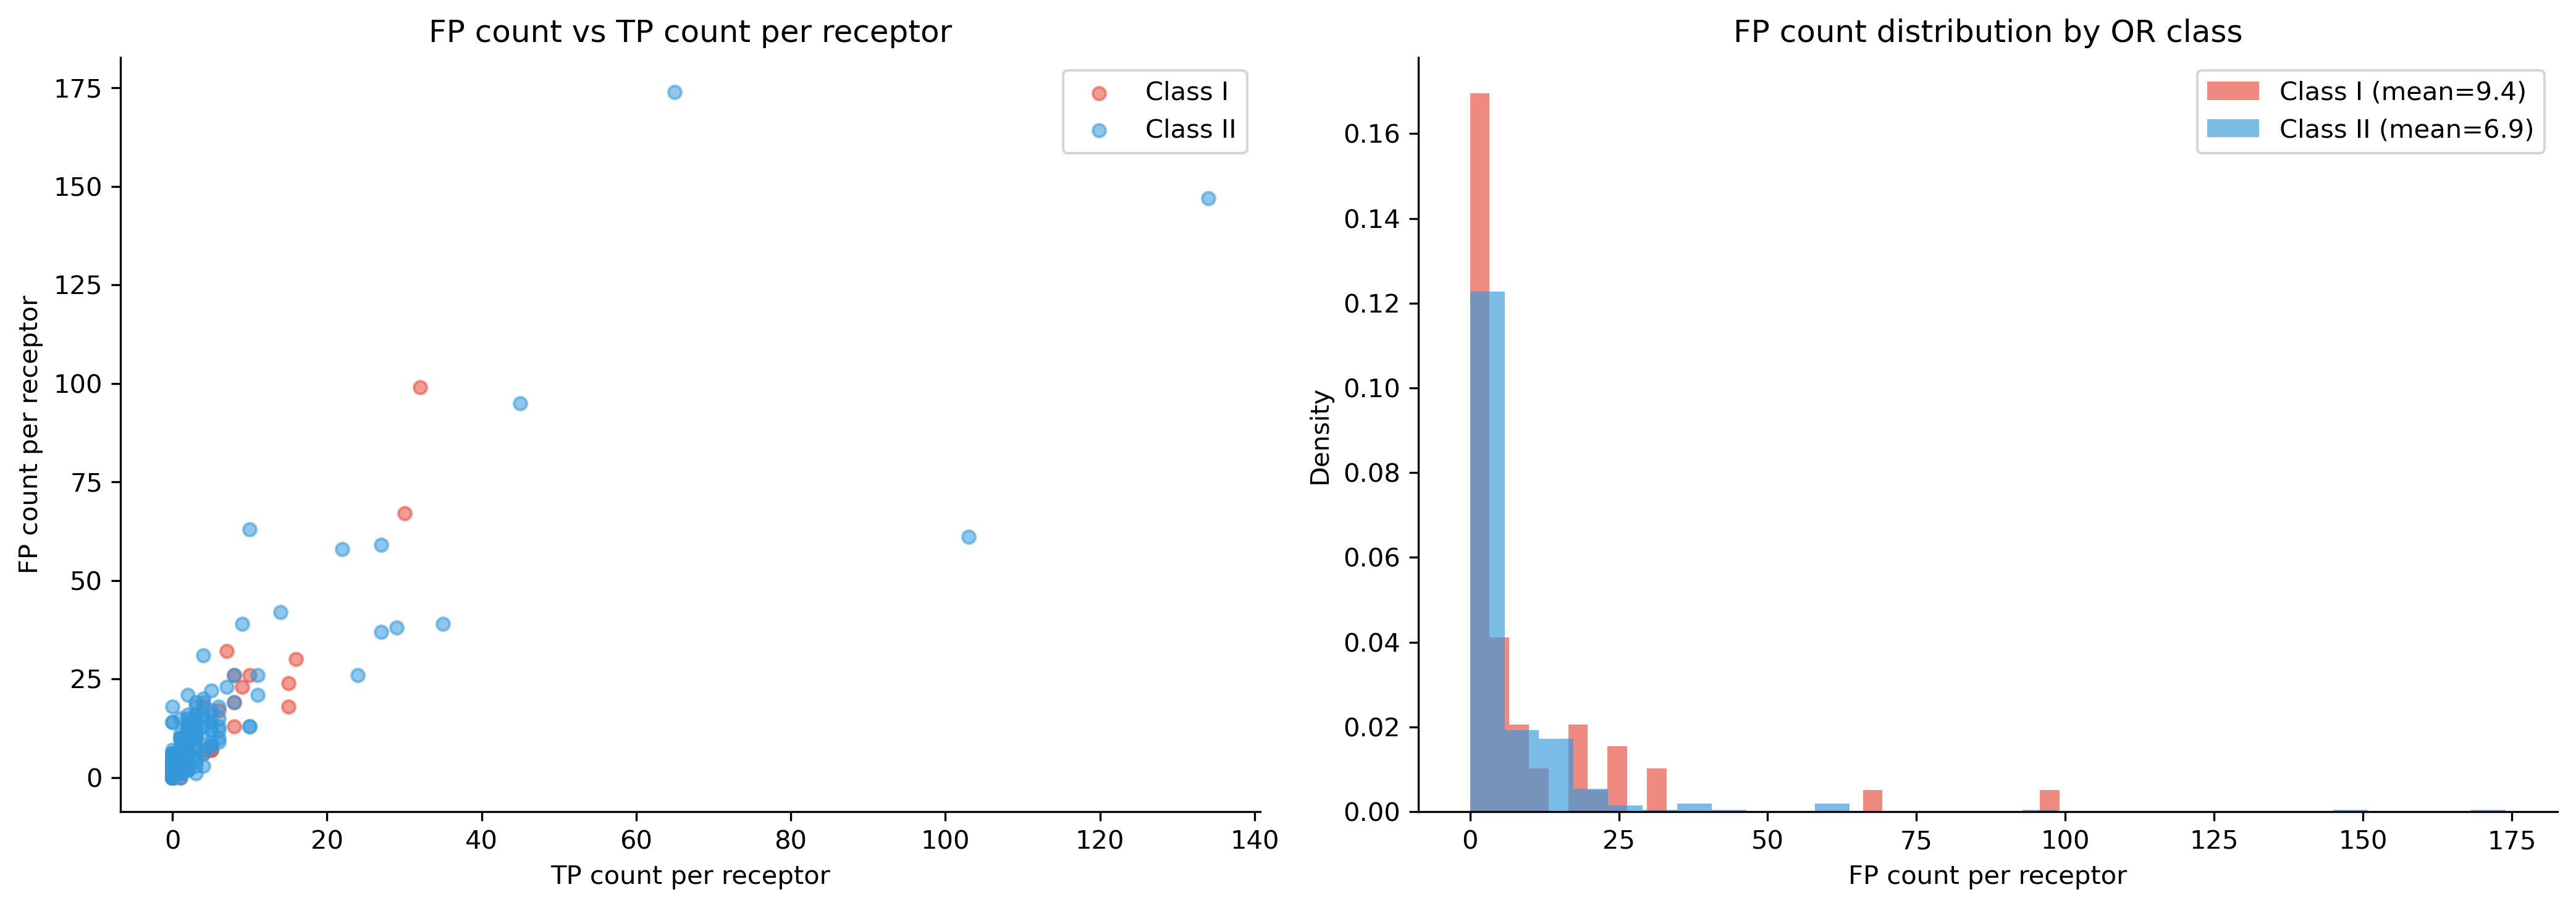

FP rate: Class I median=0.0909, Class II median=0.0645
Mann-Whitney U p=8.6364e-03


In [17]:
# Focus on receptors with at least one FP
fp_receptors = receptor_stats[receptor_stats.FP_count > 0].sort_values(
    ['OR_class', 'FP_count'], ascending=[True, False]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FP count vs TP count per receptor (scatter)
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    sub = receptor_stats[receptor_stats.OR_class == cls]
    axes[0].scatter(sub.TP_count, sub.FP_count, alpha=0.55, color=color, s=25, label=label)
axes[0].set_xlabel('TP count per receptor')
axes[0].set_ylabel('FP count per receptor')
axes[0].set_title('FP count vs TP count per receptor')
axes[0].legend()

# Distribution of FP counts (log scale)
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    data = receptor_stats[receptor_stats.OR_class == cls]['FP_count']
    axes[1].hist(data, bins=30, alpha=0.65, color=color, density=True,
                label=f'{label} (mean={data.mean():.1f})')
axes[1].set_xlabel('FP count per receptor')
axes[1].set_ylabel('Density')
axes[1].set_title('FP count distribution by OR class')
axes[1].legend()

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/receptor_fp_tp_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Wilcoxon rank-sum: Class I vs Class II FP rate
c1_fprate = receptor_stats[receptor_stats.OR_class == 'class 1']['FP_rate'].dropna()
c2_fprate = receptor_stats[receptor_stats.OR_class == 'class 2']['FP_rate'].dropna()
_, p_fprate = mannwhitneyu(c1_fprate, c2_fprate, alternative='two-sided')
print(f"FP rate: Class I median={c1_fprate.median():.4f}, Class II median={c2_fprate.median():.4f}")
print(f"Mann-Whitney U p={p_fprate:.4e}")

## 9. Summary

In [18]:
print("=" * 70)
print("SUMMARY OF FP/FN EXPLORATION")
print("=" * 70)

print(f"""
Dataset
  Total pairs      : {len(cp):,}
  Unique proteins  : {cp.uniprot_id.nunique()}
  Unique odorants  : {cp.smiles_id.nunique()}

Confusion matrix
  TP : {len(tp):>6,}  ({len(tp)/len(cp)*100:.1f}%)
  TN : {len(tn):>6,}  ({len(tn)/len(cp)*100:.1f}%)
  FP : {len(fp):>6,}  ({len(fp)/len(cp)*100:.1f}%)
  FN : {len(fn):>6,}  ({len(fn)/len(cp)*100:.1f}%)

False Positives ({len(fp):,} pairs)
  Receptors with ≥1 FP  : {(receptor_stats.FP_count>0).sum()} / {len(receptor_stats)}
  Odorants with ≥1 FP   : {(odorant_stats.FP_count>0).sum()} / {len(odorant_stats)}
  FP prob range          : {fp.probability.min():.3f} – {fp.probability.max():.3f} (med={fp.probability.median():.3f})

False Negatives ({len(fn)} pairs)
  Unique proteins        : {fn.uniprot_id.nunique()}
  Unique odorants        : {fn.smiles_id.nunique()}
  FN prob range          : {fn.probability.min():.3f} – {fn.probability.max():.3f} (med={fn.probability.median():.3f})
""")

SUMMARY OF FP/FN EXPLORATION

Dataset
  Total pairs      : 23,782
  Unique proteins  : 409
  Unique odorants  : 652

Confusion matrix
  TP :  1,101  (4.6%)
  TN : 19,667  (82.7%)
  FP :  2,987  (12.6%)
  FN :     27  (0.1%)

False Positives (2,987 pairs)
  Receptors with ≥1 FP  : 395 / 409
  Odorants with ≥1 FP   : 410 / 652
  FP prob range          : 0.500 – 0.986 (med=0.800)

False Negatives (27 pairs)
  Unique proteins        : 24
  Unique odorants        : 19
  FN prob range          : 0.010 – 0.492 (med=0.274)



## 10. Phylogenetic Distance Analysis

Three complementary views on whether misclassified pairs occupy distinct positions on the OR phylogenetic tree:

1. **Per-odorant cross-distances** — for each odorant, compare the branch distance of FP receptors to TP receptors vs TN receptors to TP receptors. Tests whether the model makes FP predictions for receptors that are phylogenetically close to true binders of the same odorant.
2. **Within-category pooled distances** — pairwise branch distances among receptors pooled by CM category. Tests whether FP/FN-prone receptors form a phylogenetically cohesive group or are scattered across the tree.
3. **Per-receptor: mean branch distance vs FP rate** — correlates each receptor's average phylogenetic distance to all other receptors with its FP rate.

In [19]:
import newick as nwk

TREE_FILE   = '/home/izirdeli/Documents.cglab/MANUSCRIPT/05_branch_VS_embedding_distance/tree-1.tree'
BRANCH_MAT  = '/home/izirdeli/Documents.cglab/MANUSCRIPT/05_branch_VS_embedding_distance/branch_dist_matrix_tree1.npy'

# Load matrix
branch_dist = np.load(BRANCH_MAT)

# Rebuild leaf order (same order used when the matrix was computed)
tree_root = nwk.read(TREE_FILE)[0]
tree_leaves = [l.name for l in tree_root.get_leaves()]

# Build uniprot → matrix-row index, stripping the taxid prefix
leaf_to_idx = {name.replace('9606.', ''): i for i, name in enumerate(tree_leaves)}

# Verify all proteins in common_pairs are present
cp_proteins = cp.uniprot_id.unique()
missing = [p for p in cp_proteins if p not in leaf_to_idx]
print(f"Tree leaves   : {len(tree_leaves)}")
print(f"Proteins in CSV : {len(cp_proteins)}")
print(f"Missing from tree : {len(missing)}")

Tree leaves   : 433
Proteins in CSV : 409
Missing from tree : 0


In [20]:
# ── Analysis 1: Per-odorant cross-distances ──────────────────────────────────
#
# For each odorant, collect branch distances between:
#   FP receptors ↔ TP receptors  (false-positive receptors vs true binders)
#   TN receptors ↔ TP receptors  (true-negative receptors vs true binders)  ← baseline
#   FN receptors ↔ TP receptors  (missed positives vs confirmed binders)
#
# Hypothesis: FP receptors are phylogenetically closer to TP receptors than
# TN receptors are, suggesting the model is confused by evolutionary similarity.

from itertools import product as iterprod

cross_fp_tp, cross_tn_tp, cross_fn_tp = [], [], []

for smiles_id, grp in cp.groupby('smiles_id'):
    idx_fp = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='FP','uniprot_id'] if u in leaf_to_idx]
    idx_tp = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='TP','uniprot_id'] if u in leaf_to_idx]
    idx_tn = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='TN','uniprot_id'] if u in leaf_to_idx]
    idx_fn = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='FN','uniprot_id'] if u in leaf_to_idx]

    if idx_tp:
        if idx_fp:
            cross_fp_tp.extend(branch_dist[i, j] for i, j in iterprod(idx_fp, idx_tp) if i != j)
        if idx_tn:
            cross_tn_tp.extend(branch_dist[i, j] for i, j in iterprod(idx_tn, idx_tp) if i != j)
        if idx_fn:
            cross_fn_tp.extend(branch_dist[i, j] for i, j in iterprod(idx_fn, idx_tp) if i != j)

cross_fp_tp = np.array(cross_fp_tp)
cross_tn_tp = np.array(cross_tn_tp)
cross_fn_tp = np.array(cross_fn_tp)

print(f"Cross-distances computed:")
print(f"  FP↔TP : {len(cross_fp_tp):,}  (median={np.median(cross_fp_tp):.4f})")
print(f"  TN↔TP : {len(cross_tn_tp):,}  (median={np.median(cross_tn_tp):.4f})")
print(f"  FN↔TP : {len(cross_fn_tp):,}  (median={np.median(cross_fn_tp):.4f})")

_, p_fp_tn = mannwhitneyu(cross_fp_tp, cross_tn_tp, alternative='two-sided')
print(f"\nMann-Whitney U (FP↔TP vs TN↔TP): p={p_fp_tn:.4e}")

Cross-distances computed:
  FP↔TP : 34,462  (median=3.5669)
  TN↔TP : 79,994  (median=3.6318)
  FN↔TP : 82  (median=3.7291)

Mann-Whitney U (FP↔TP vs TN↔TP): p=3.1831e-25


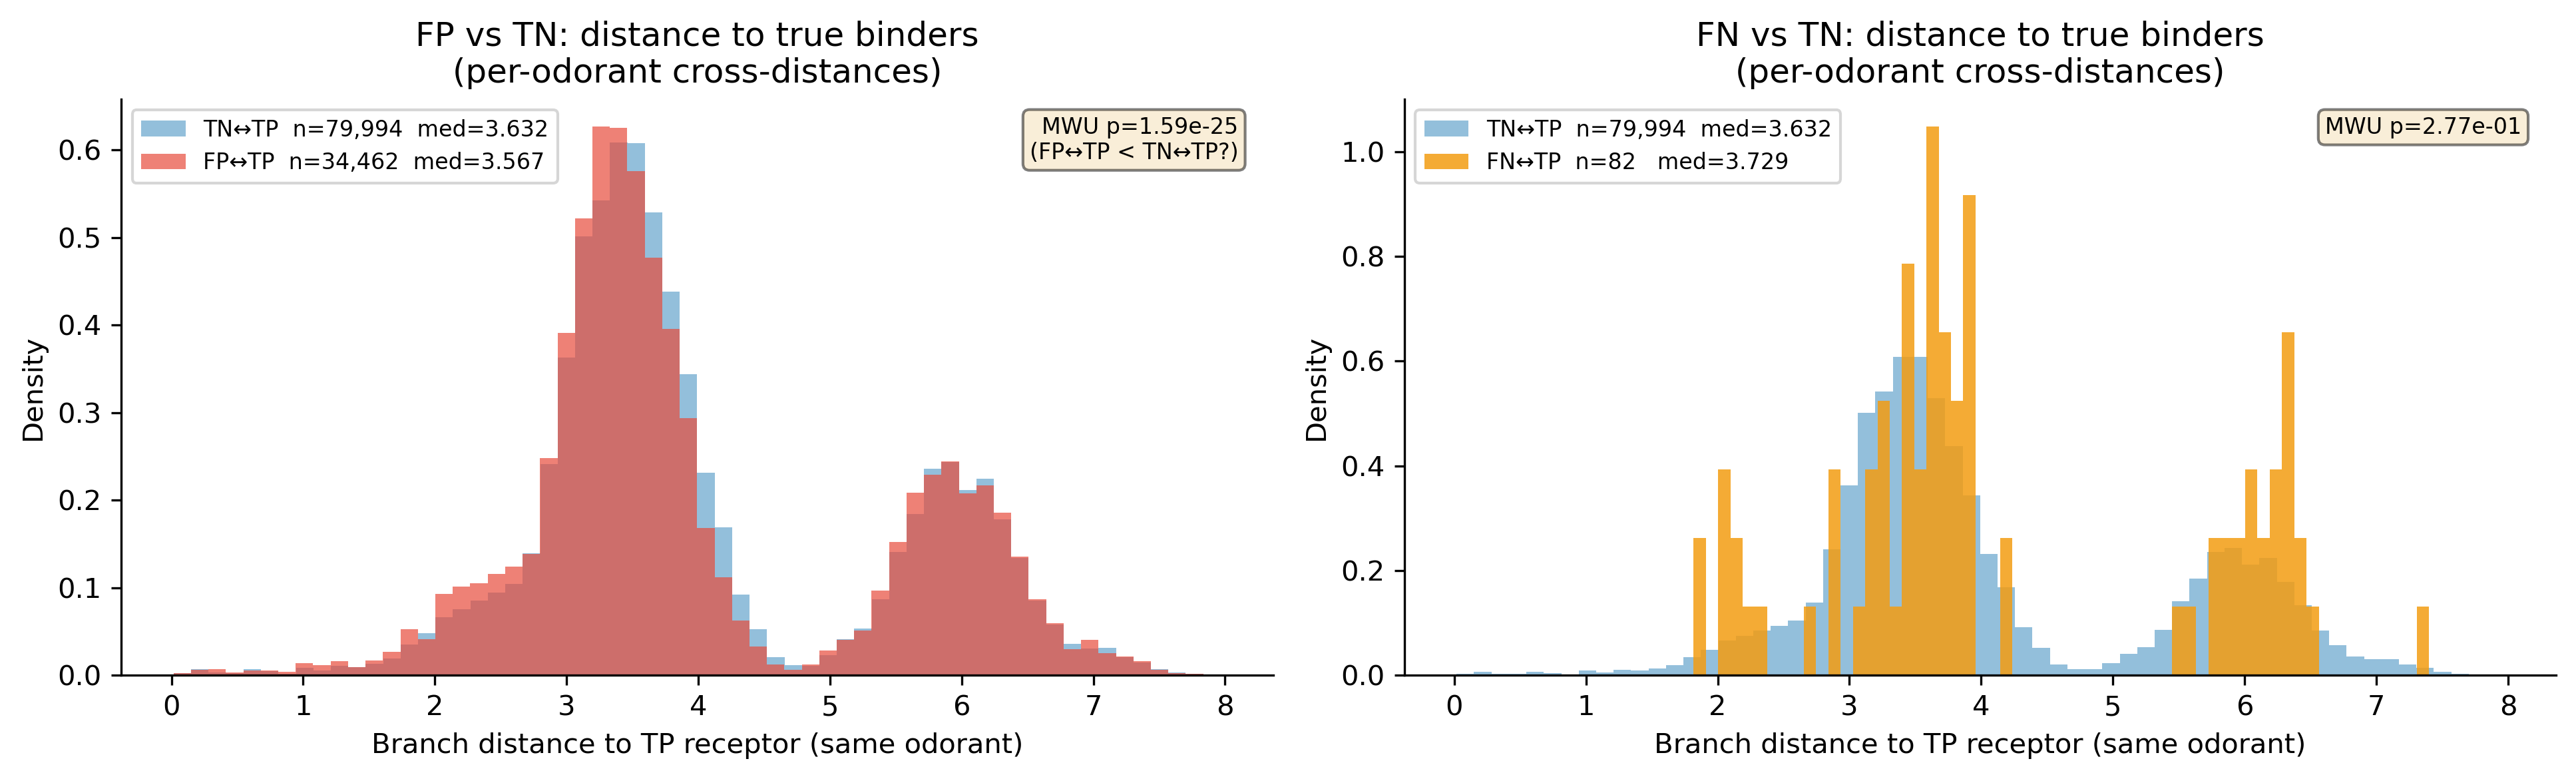

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: FP↔TP vs TN↔TP
for data, label, color, alpha in [
    (cross_tn_tp, f'TN↔TP  n={len(cross_tn_tp):,}  med={np.median(cross_tn_tp):.3f}', '#2980b9', 0.5),
    (cross_fp_tp, f'FP↔TP  n={len(cross_fp_tp):,}  med={np.median(cross_fp_tp):.3f}', '#e74c3c', 0.7),
]:
    axes[0].hist(data, bins=60, density=True, alpha=alpha, color=color, label=label)
axes[0].set_xlabel('Branch distance to TP receptor (same odorant)')
axes[0].set_ylabel('Density')
axes[0].set_title('FP vs TN: distance to true binders\n(per-odorant cross-distances)')
axes[0].legend(fontsize=8)

_, p_fp_tn2 = mannwhitneyu(cross_fp_tp, cross_tn_tp, alternative='less')
axes[0].text(0.97, 0.97, f'MWU p={p_fp_tn2:.2e}\n(FP↔TP < TN↔TP?)',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel 2: FN↔TP vs TN↔TP
for data, label, color, alpha in [
    (cross_tn_tp, f'TN↔TP  n={len(cross_tn_tp):,}  med={np.median(cross_tn_tp):.3f}', '#2980b9', 0.5),
    (cross_fn_tp, f'FN↔TP  n={len(cross_fn_tp):,}   med={np.median(cross_fn_tp):.3f}', '#f39c12', 0.85),
]:
    axes[1].hist(data, bins=60, density=True, alpha=alpha, color=color, label=label)
axes[1].set_xlabel('Branch distance to TP receptor (same odorant)')
axes[1].set_ylabel('Density')
axes[1].set_title('FN vs TN: distance to true binders\n(per-odorant cross-distances)')
axes[1].legend(fontsize=8)

_, p_fn_tn2 = mannwhitneyu(cross_fn_tp, cross_tn_tp, alternative='two-sided')
axes[1].text(0.97, 0.97, f'MWU p={p_fn_tn2:.2e}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/phylo_cross_distances_per_odorant.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# ── Analysis 2: Within-category pooled pairwise distances ────────────────────
#
# Pool unique receptors that appear in at least one pair of each CM category
# (a receptor can belong to multiple pools). Compute all pairwise branch
# distances within each pool and compare distributions.
# Question: are FP-prone receptors phylogenetically clustered or dispersed?

from scipy.stats import spearmanr

pool_idxs = {}
for cat in ['TN', 'FP', 'TP', 'FN']:
    uniprots = cp[cp.cm_category == cat]['uniprot_id'].unique()
    pool_idxs[cat] = [leaf_to_idx[u] for u in uniprots if u in leaf_to_idx]
    print(f"  {cat}: {len(pool_idxs[cat])} unique receptors")

print()
within_dists = {}
for cat, idxs in pool_idxs.items():
    dists = [branch_dist[idxs[a], idxs[b]]
             for a in range(len(idxs)) for b in range(a+1, len(idxs))]
    within_dists[cat] = np.array(dists)
    print(f"  {cat}: {len(dists):,} within-pool pairs  "
          f"median={np.median(dists):.4f}  mean={np.mean(dists):.4f}")

print()
print("Mann-Whitney U tests (vs TN pool as baseline):")
tn_d = within_dists['TN']
for cat in ['FP', 'TP', 'FN']:
    _, p = mannwhitneyu(within_dists[cat], tn_d, alternative='two-sided')
    print(f"  {cat} vs TN: p={p:.4e}")

  TN: 407 unique receptors
  FP: 395 unique receptors
  TP: 176 unique receptors
  FN: 24 unique receptors

  TN: 82,621 within-pool pairs  median=3.5836  mean=3.9685
  FP: 77,815 within-pool pairs  median=3.5774  mean=3.9667
  TP: 15,400 within-pool pairs  median=3.6186  mean=4.1362
  FN: 276 within-pool pairs  median=3.6455  mean=3.9528

Mann-Whitney U tests (vs TN pool as baseline):
  FP vs TN: p=3.5097e-01
  TP vs TN: p=1.5070e-19
  FN vs TN: p=6.0443e-01


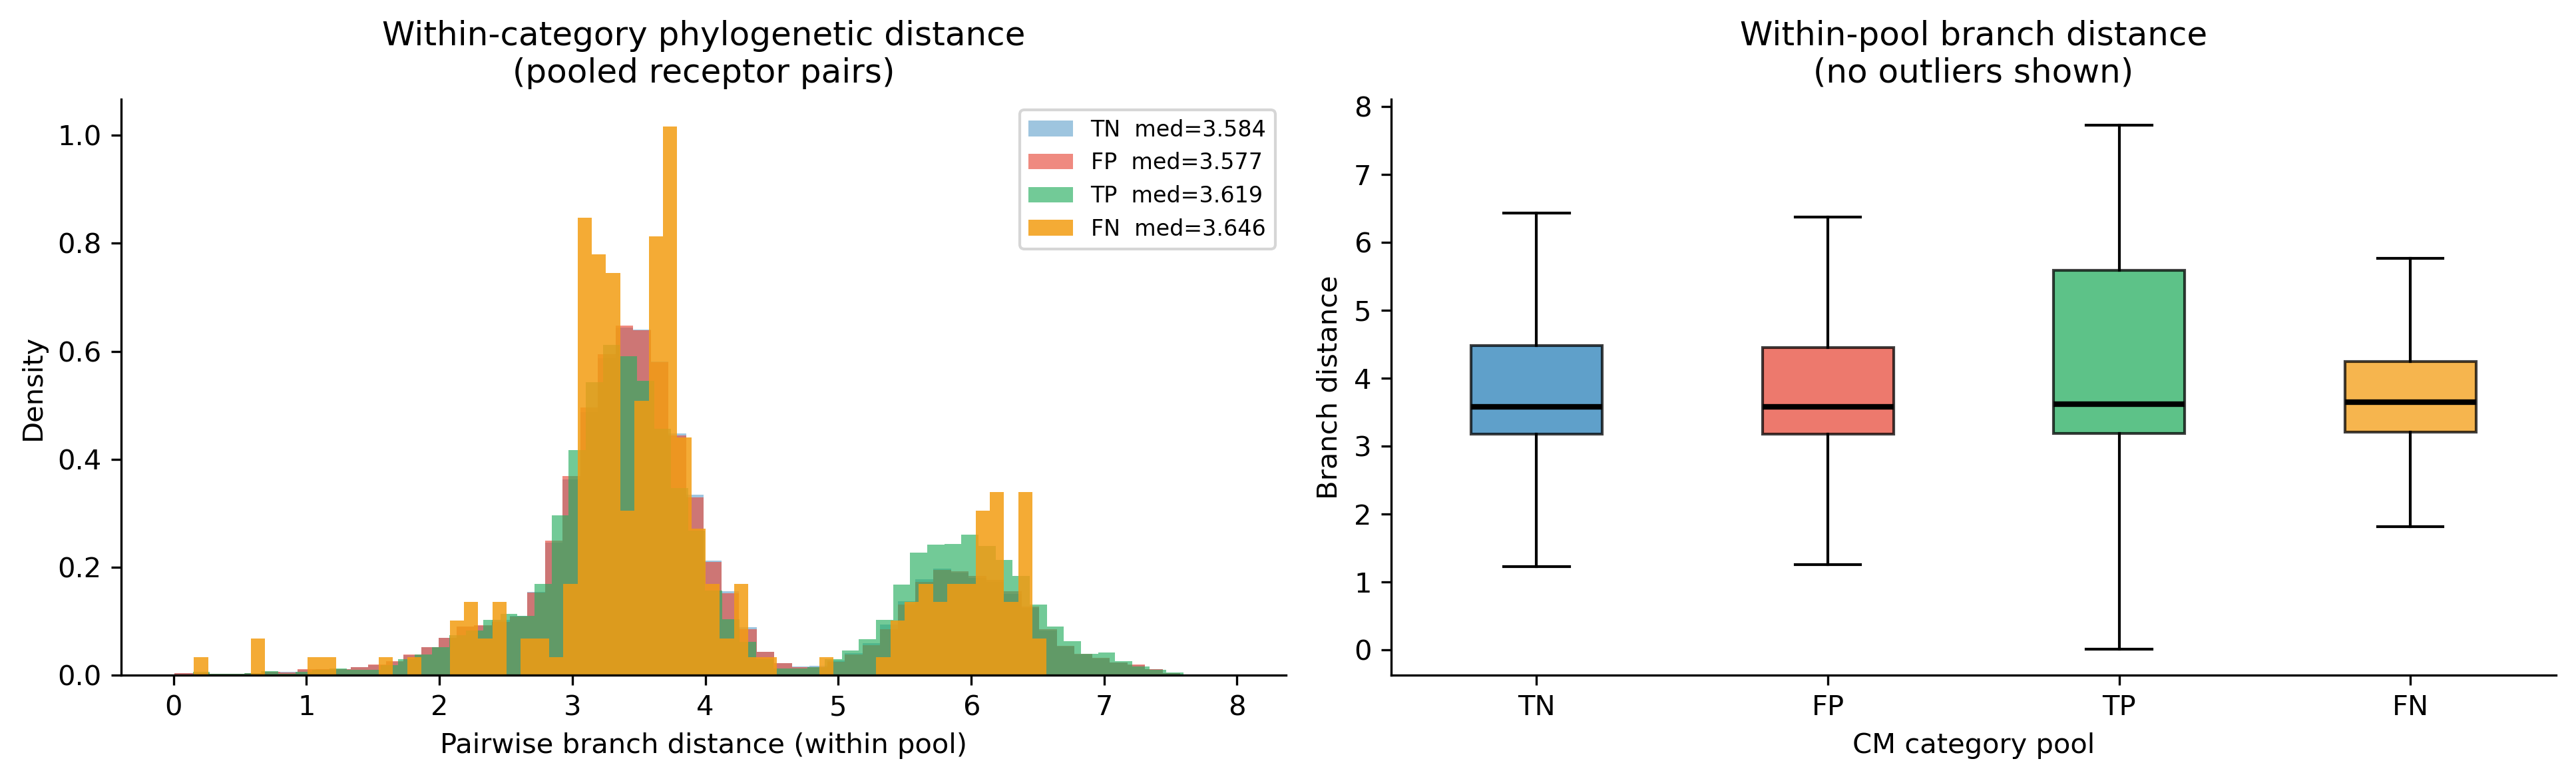

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: overlapping histograms of within-pool distances
for cat, color, alpha in [('TN','#2980b9',0.45), ('FP','#e74c3c',0.65),
                           ('TP','#27ae60',0.65), ('FN','#f39c12',0.85)]:
    d = within_dists[cat]
    axes[0].hist(d, bins=60, density=True, alpha=alpha, color=color,
                 label=f'{cat}  med={np.median(d):.3f}')
axes[0].set_xlabel('Pairwise branch distance (within pool)')
axes[0].set_ylabel('Density')
axes[0].set_title('Within-category phylogenetic distance\n(pooled receptor pairs)')
axes[0].legend(fontsize=8)

# Panel 2: boxplot summary
bp_data  = [within_dists[c] for c in ['TN','FP','TP','FN']]
bp = axes[1].boxplot(bp_data, labels=['TN','FP','TP','FN'], patch_artist=True,
                     medianprops={'color':'black','linewidth':2}, showfliers=False)
for patch, cat in zip(bp['boxes'], ['TN','FP','TP','FN']):
    patch.set_facecolor(CAT_COLORS[cat]); patch.set_alpha(0.75)
axes[1].set_xlabel('CM category pool')
axes[1].set_ylabel('Branch distance')
axes[1].set_title('Within-pool branch distance\n(no outliers shown)')

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/phylo_within_pool_distances.png', dpi=300, bbox_inches='tight')
plt.show()

Spearman ρ (mean branch dist vs FP rate): 0.0346  p=4.8558e-01
Spearman ρ (mean branch dist vs TP rate): 0.0660  p=1.8266e-01


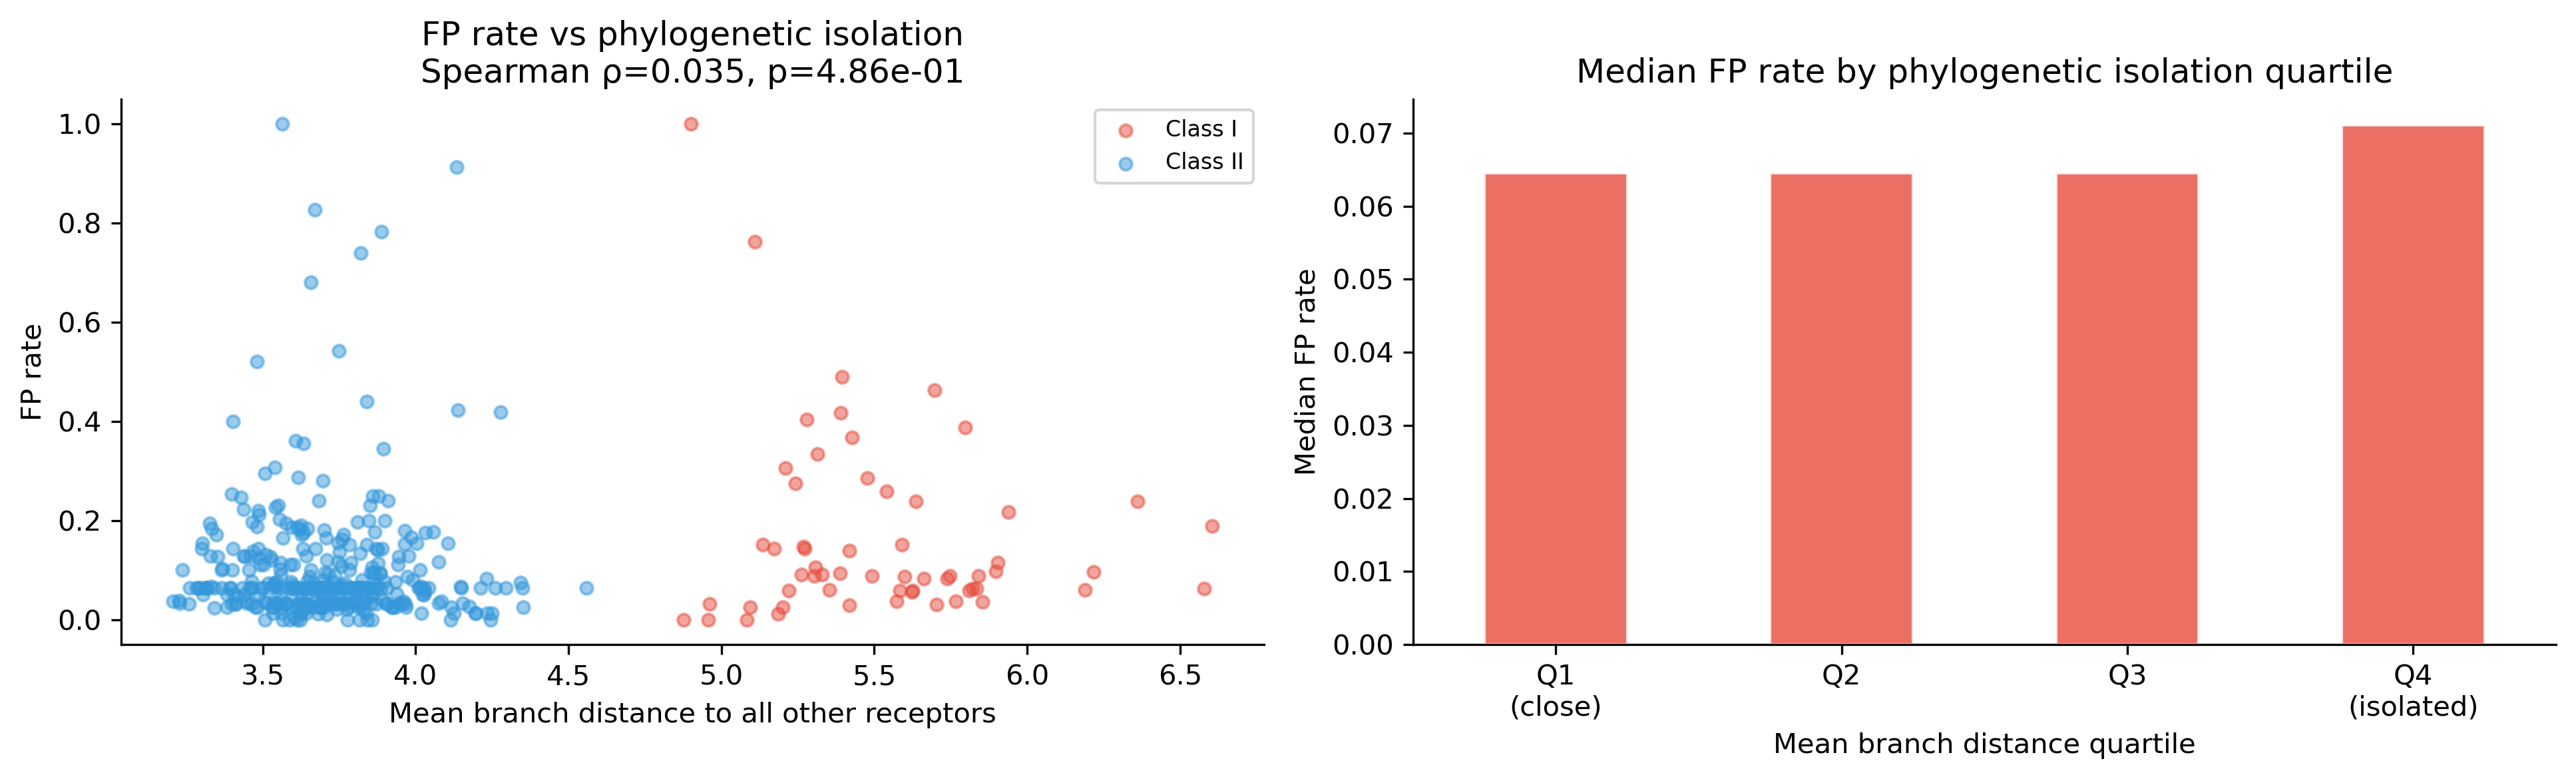

In [24]:
# ── Analysis 3: Per-receptor mean branch distance vs FP rate ─────────────────
#
# For each receptor in common_pairs, compute its mean branch distance to all
# other receptors in the same 409-protein set, then correlate with FP rate.
# Hypothesis: phylogenetically isolated receptors may generate more FPs because
# the model has fewer similar sequences to learn from.

cp_prot_list = list(cp_proteins)
cp_prot_idxs = [leaf_to_idx[u] for u in cp_prot_list]

mean_branch = {}
for i, u in enumerate(cp_prot_list):
    row_vals = [branch_dist[cp_prot_idxs[i], cp_prot_idxs[j]]
                for j in range(len(cp_prot_list)) if i != j]
    mean_branch[u] = np.mean(row_vals)

receptor_stats['mean_branch_dist'] = receptor_stats['uniprot_id'].map(mean_branch)
receptor_stats['TP_rate'] = receptor_stats['TP_count'] / receptor_stats['total_pairs']

rho_fp, p_fp = spearmanr(receptor_stats['mean_branch_dist'], receptor_stats['FP_rate'])
rho_tp, p_tp = spearmanr(receptor_stats['mean_branch_dist'], receptor_stats['TP_rate'])

print(f"Spearman ρ (mean branch dist vs FP rate): {rho_fp:.4f}  p={p_fp:.4e}")
print(f"Spearman ρ (mean branch dist vs TP rate): {rho_tp:.4f}  p={p_tp:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    sub = receptor_stats[receptor_stats.OR_class == cls]
    axes[0].scatter(sub.mean_branch_dist, sub.FP_rate,
                    alpha=0.5, color=color, s=20, label=label)
axes[0].set_xlabel('Mean branch distance to all other receptors')
axes[0].set_ylabel('FP rate')
axes[0].set_title(f'FP rate vs phylogenetic isolation\nSpearman ρ={rho_fp:.3f}, p={p_fp:.2e}')
axes[0].legend(fontsize=8)

receptor_stats['bd_quartile'] = pd.qcut(receptor_stats['mean_branch_dist'], 4,
                                         labels=['Q1\n(close)', 'Q2', 'Q3', 'Q4\n(isolated)'])
q_fp = receptor_stats.groupby('bd_quartile', observed=True)['FP_rate'].median()
q_fp.plot(kind='bar', ax=axes[1], color='#e74c3c', alpha=0.8, width=0.5, edgecolor='white')
axes[1].set_xlabel('Mean branch distance quartile')
axes[1].set_ylabel('Median FP rate')
axes[1].set_title('Median FP rate by phylogenetic isolation quartile')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
#plt.savefig(f'{OUT_DIR}/phylo_mean_dist_vs_fp_rate.png', dpi=300, bbox_inches='tight')
plt.show()